# Parameter Recovery and Model Validation

Before trusting any inference method on real data, we must validate on
**mock data where we know the truth**.  This notebook performs systematic
recovery tests across two regimes:

- **Part A: Parametric model** (7 free parameters) — smooth SFH,
  comparable to BAGPIPES / Prospector.  NUTS is the gold standard.
- **Part B: Stochastic model** ($\sim 137$ free parameters) — IFT
  correlated-field SFH with PSD-governed burstiness.  Ray Tracing and
  geoVI are the primary samplers.
- **Part C: Robustness** — SNR dependence, derived quantities, and
  posterior predictive checks.

These results directly support the claims made in the paper (Figs. 4--7).
Population-level (hierarchical) PSD recovery is deferred to
**Tutorial 05**.

In [1]:
import time

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, safe_corner
setup_style()

from diffsed import (
    Model, ParamSpec, Uniform, Gaussian, LogUniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)

ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
print(f"SSP grid loaded — {len(ssp_data.ssp_lgmet)} metallicities, "
      f"{len(ssp_data.ssp_lg_age_gyr)} ages")
print(f"Filters loaded — {[fc.name for fc in filters[2]]}")

SSP grid loaded — 15 metallicities, 93 ages
Filters loaded — ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z']


## Part A: Parametric Model (7 free parameters)

A smooth double-power-law SFH with no stochastic component
(`psd_sigma = 0`).  This is the regime where **diffsed** competes
directly with BAGPIPES and Prospector.  With only 7 free parameters,
**NUTS** gives exact, gold-standard posteriors in $\sim 30$ s.

W0315 10:58:56.598694 4823084 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Free parameters: 7
Observed bands:  5


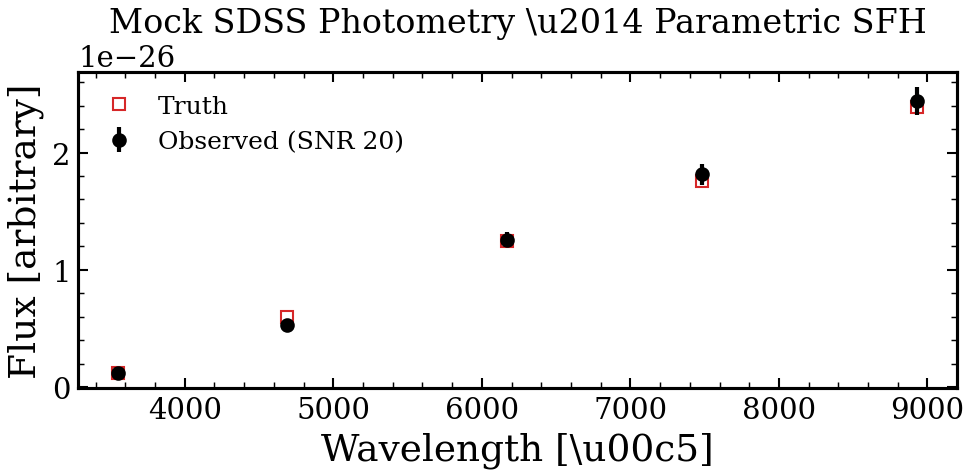

In [2]:
spec_param = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Fixed(0.0),
    psd_tau_myr=Fixed(50.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=False,
)
model_param = Model(spec_param, ssp_data, filters=filters)

key = jax.random.PRNGKey(42)
true_param = spec_param.sample(key)
mock_param = model_param.mock(true_param, snr=20.0, key=key)

print(f"Free parameters: {spec_param.n_free}")
print(f"Observed bands:  {mock_param.flux_obs.shape[0]}")

# --- Quick look at mock SED ---
fig, ax = plt.subplots(figsize=(7, 3.5))
wave_eff = jnp.array([3551, 4686, 6166, 7480, 8932])  # SDSS ugriz
ax.errorbar(wave_eff, mock_param.flux_obs, yerr=mock_param.noise,
            fmt="o", color="k", label="Observed (SNR 20)", zorder=3)
ax.plot(wave_eff, mock_param.flux_true, "s", ms=6, mfc="none",
        color="C3", label="Truth")
ax.set_xlabel("Wavelength [\\u00c5]")
ax.set_ylabel("Flux [arbitrary]")
ax.set_title("Mock SDSS Photometry \\u2014 Parametric SFH")
ax.legend()
plt.tight_layout()
plt.show()

  Step     0/500: loss = 181.0655
  Step   200/500: loss = 1.5823
  Step   400/500: loss = 1.4830
  Step   499/500: loss = 1.4762
  MAP (ADAM) complete in 0.2s, 500 steps
MAP finished in 0.3s
Ray Tracing: 7 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0794


  Ray Tracing complete in 0.3s. Acceptance: 58.2% (overall), 66.2% (post burn-in). Samples: 300
RT finished in 0.8s


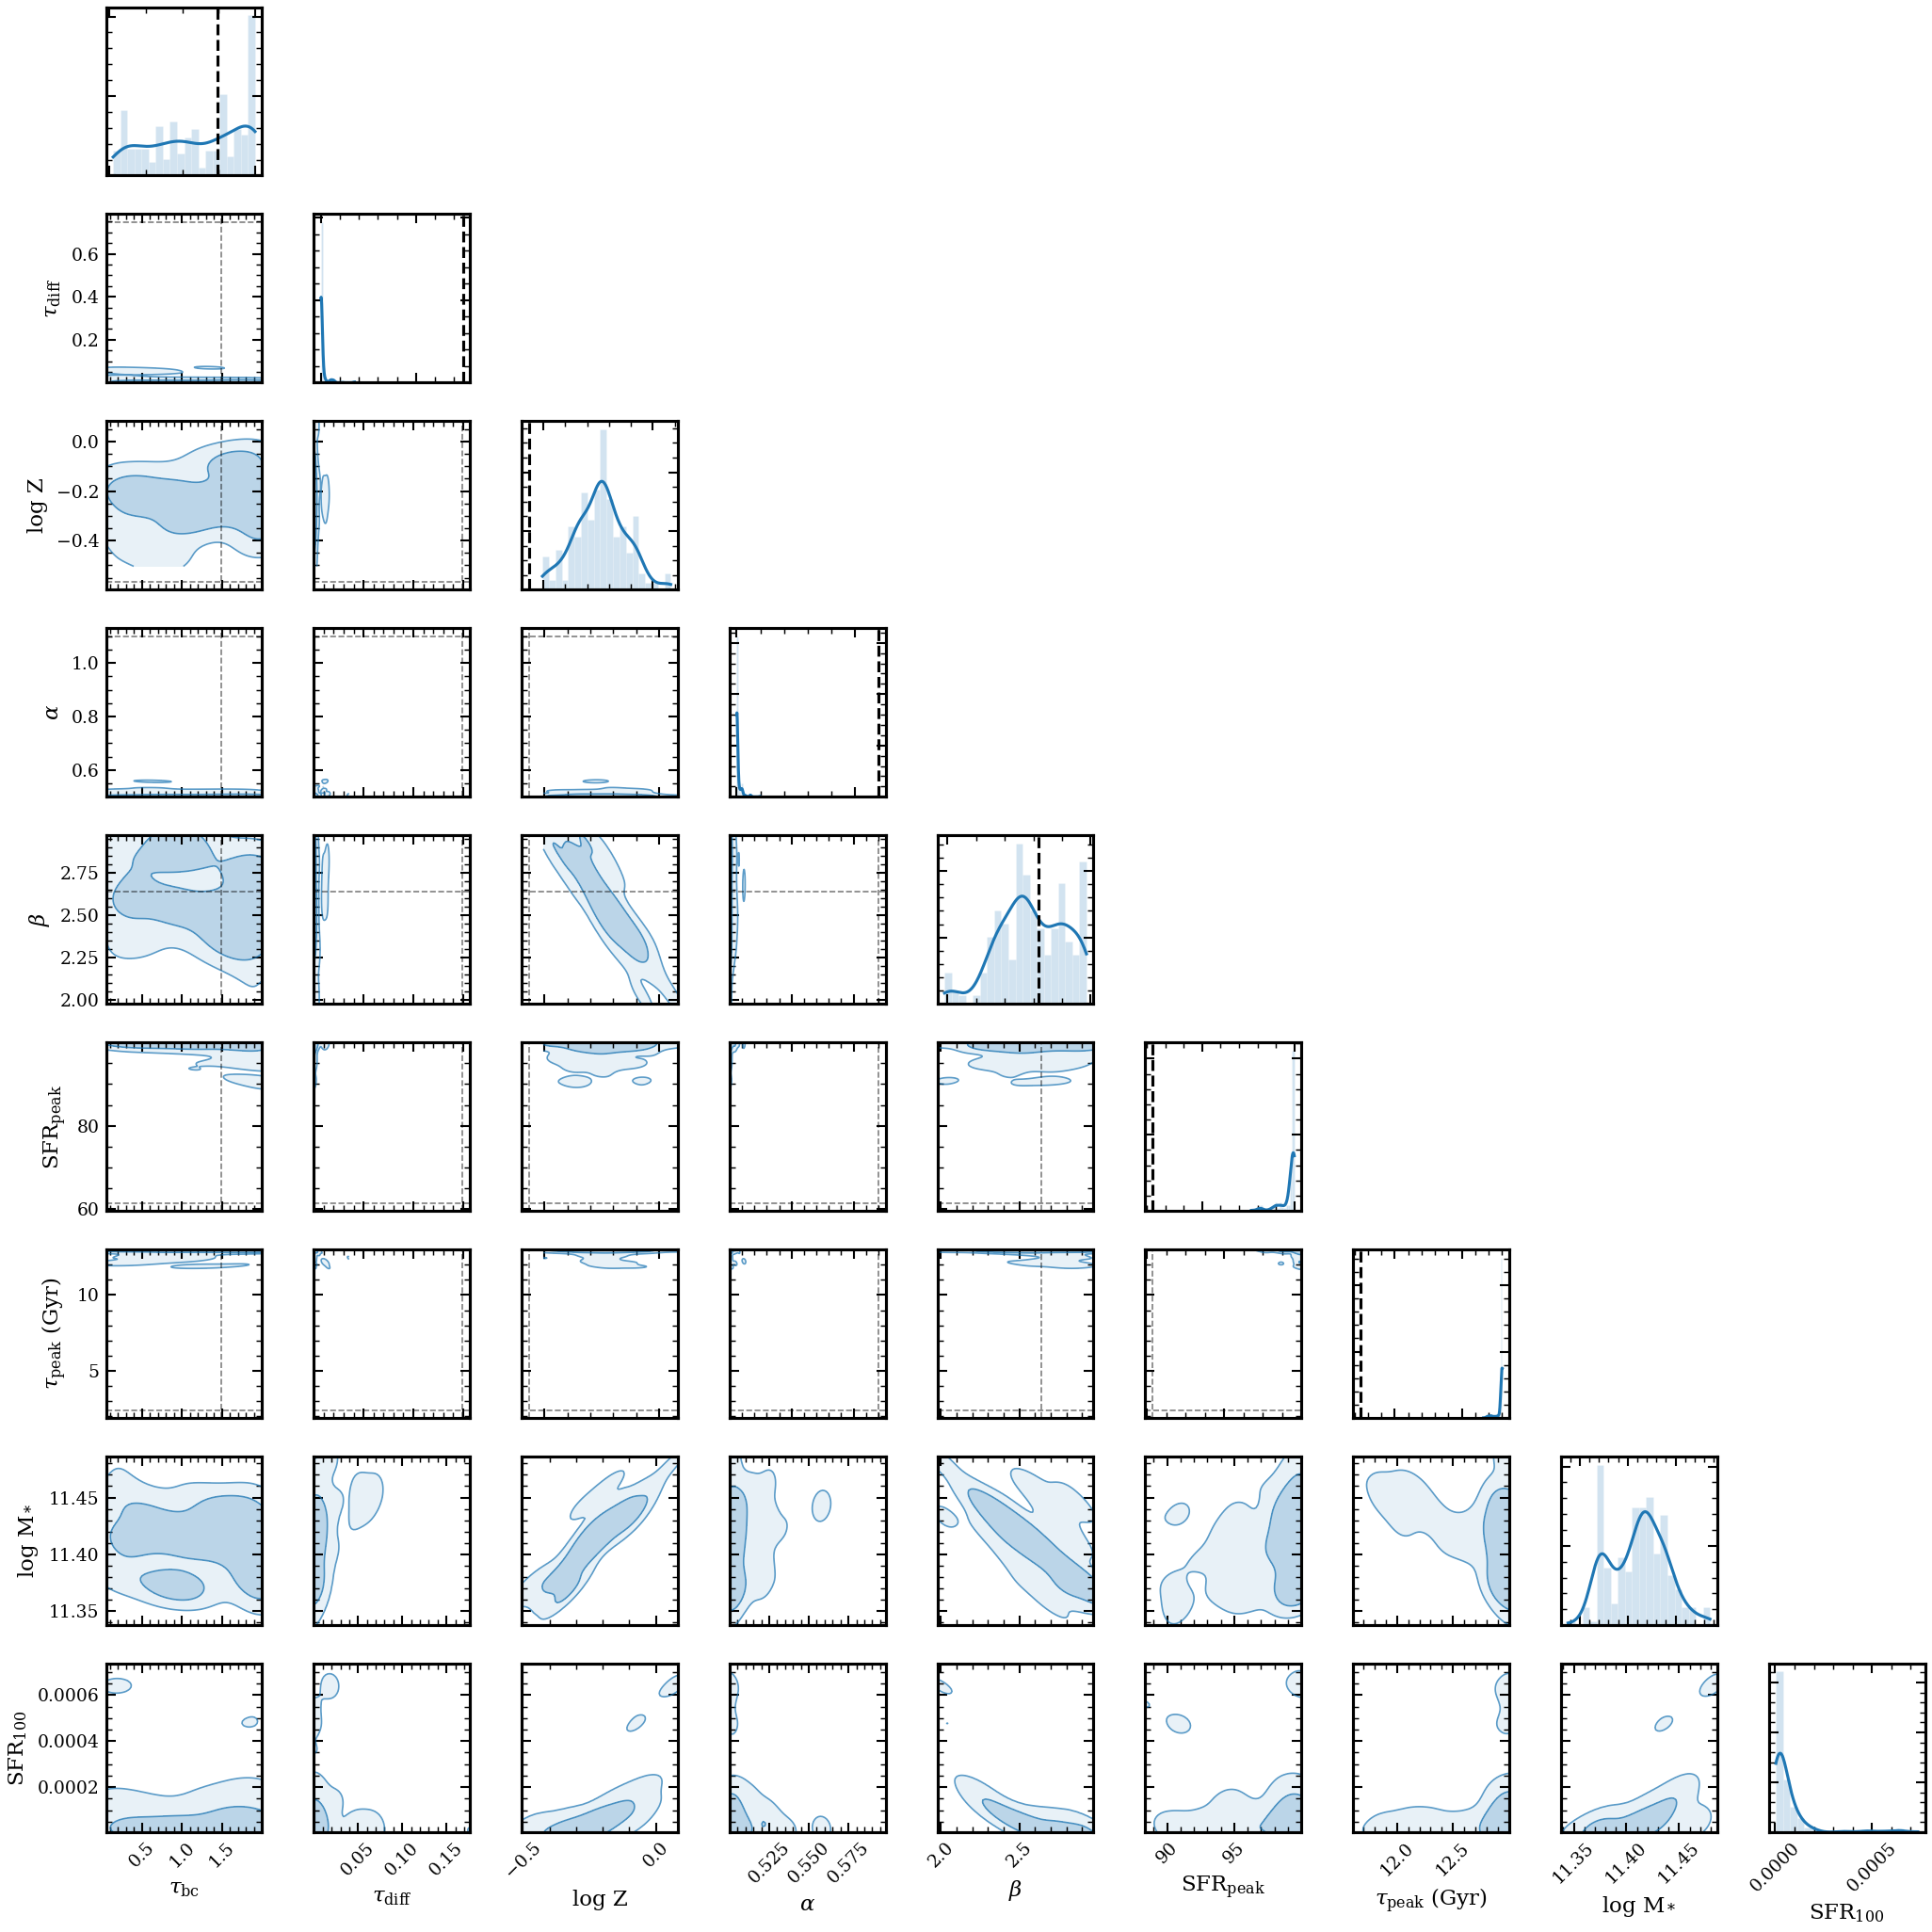

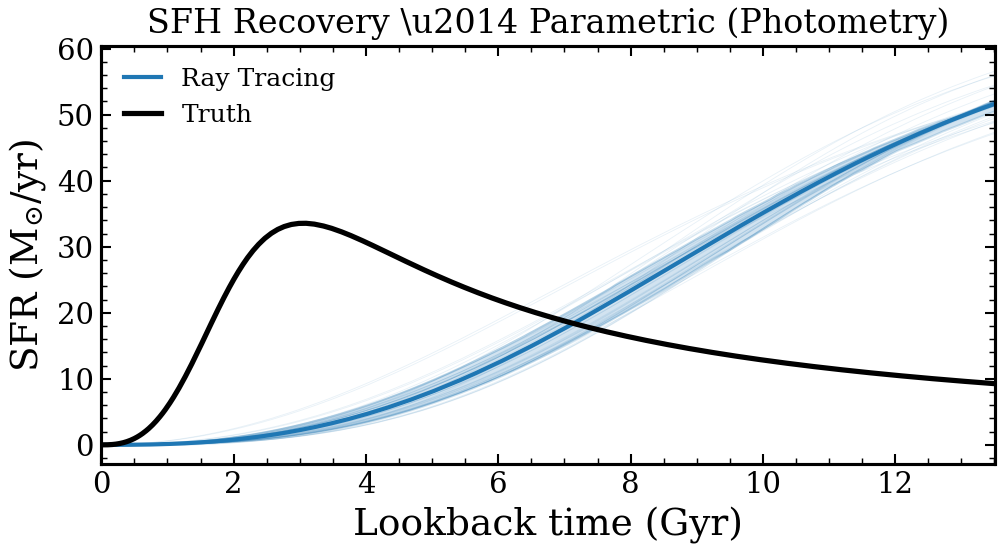

  dust_tau_bc         : truth=1.484  68%CI=[0.411, 1.967]  OK
  dust_tau_diff       : truth=0.748  68%CI=[0.000, 0.006]  MISS
  met_logzsol         : truth=-0.566  68%CI=[-0.353, -0.126]  MISS
  sfh_alpha           : truth=1.099  68%CI=[0.500, 0.511]  MISS
  sfh_beta            : truth=2.638  68%CI=[2.361, 2.849]  OK
  sfh_peak_sfr        : truth=61.511  68%CI=[96.646, 99.963]  MISS
  sfh_tau_peak_gyr    : truth=2.417  68%CI=[12.934, 13.000]  MISS
\nCoverage: 2/7 params within 68% CI


In [3]:
fitter_phot = Fitter(model_param, mock_param.flux_obs, mock_param.noise,
                     data_type="photometry")

t0 = time.perf_counter()
result_map_param = fitter_phot.run("map", n_steps=500)
print(f"MAP finished in {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
result_rt_phot = fitter_phot.run("raytrace", init_from=result_map_param,
                                   n_burnin=100, n_steps=300)
print(f"RT finished in {time.perf_counter() - t0:.1f}s")

# --- Corner plot + SFH ---
fig_corner = safe_corner(result_rt_phot, truths=true_param, color="C0",
                         label="RT (phot)")

fig_sfh, ax_sfh = plt.subplots(figsize=(7, 4))
model_param.plot_sfh_posterior(result_rt_phot, true_params=true_param,
                              color="C0", label="Ray Tracing", ax=ax_sfh)
ax_sfh.set_title("SFH Recovery \\u2014 Parametric (Photometry)")
ax_sfh.legend()
plt.tight_layout()
plt.show()

# --- Check coverage ---
samples = result_rt_phot.samples
n_recovered = 0
for name in spec_param.free_params:
    lo, hi = np.percentile(samples[name], [16, 84])
    truth = float(true_param[name])
    covered = lo <= truth <= hi
    n_recovered += int(covered)
    status = "OK" if covered else "MISS"
    print(f"  {name:20s}: truth={truth:.3f}  68%CI=[{lo:.3f}, {hi:.3f}]  {status}")
print(f"\\nCoverage: {n_recovered}/{len(spec_param.free_params)} params within 68% CI")

  Step     0/500: loss = 16172.8721


  Step   200/500: loss = 104.8066


  Step   400/500: loss = 99.4322
  Step   499/500: loss = 98.0393
  MAP (ADAM) complete in 1.2s, 500 steps
MAP (spectroscopy) finished in 1.2s
Ray Tracing: 7 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0794


  Ray Tracing complete in 0.4s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
NUTS (spectroscopy) finished in 7.5s


Corner plot skipped: Contour levels must be increasing


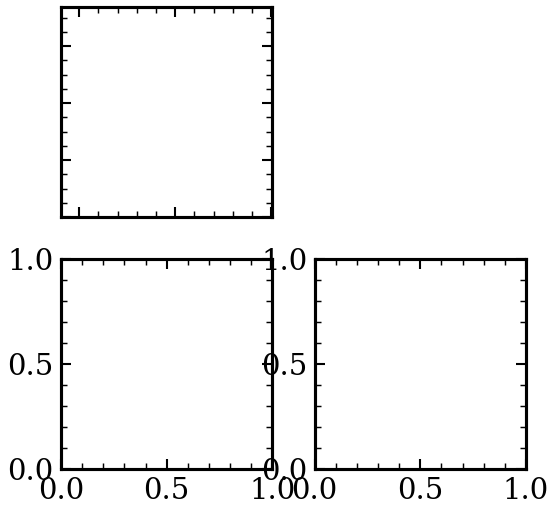

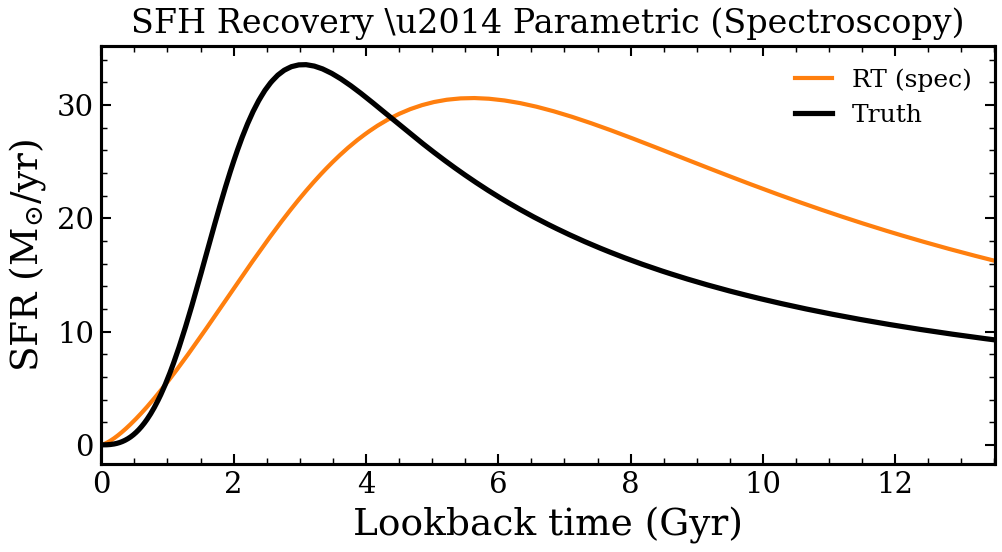

In [4]:
# Generate a 200-pixel spectrum for the same galaxy
wave_obs = jnp.linspace(3800, 9200, 200)
spec_true = model_param.predict_spectrum(true_param, wave_obs)
noise_spec = spec_true / 30.0  # SNR ~ 30 per pixel
key_spec = jax.random.PRNGKey(99)
spec_obs = spec_true + noise_spec * jax.random.normal(key_spec, spec_true.shape)

model_param._wave_obs = wave_obs
fitter_spec = Fitter(model_param, spec_obs, noise_spec,
                     data_type="spectroscopy")

t0 = time.perf_counter()
result_map_spec = fitter_spec.run("map", n_steps=500)
print(f"MAP (spectroscopy) finished in {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
result_rt_spec = fitter_spec.run("raytrace", init_from=result_map_spec,
                                   n_burnin=100, n_steps=300)
print(f"NUTS (spectroscopy) finished in {time.perf_counter() - t0:.1f}s")

fig_corner_spec = safe_corner(result_rt_spec, truths=true_param, color="C1",
                              label="RT (spec)")

fig_sfh_spec, ax_sfh_spec = plt.subplots(figsize=(7, 4))
model_param.plot_sfh_posterior(result_rt_spec, true_params=true_param,
                              color="C1", label="RT (spec)", ax=ax_sfh_spec)
ax_sfh_spec.set_title("SFH Recovery \\u2014 Parametric (Spectroscopy)")
ax_sfh_spec.legend()
plt.tight_layout()
plt.show()

### Photometry vs Spectroscopy: Information Content

Spectroscopy resolves degeneracies that broadband photometry cannot.
The most dramatic improvement is typically in metallicity and dust,
which produce similar reddening in broadband colours but have distinct
spectral features (absorption lines, continuum shape).  SFH parameters
also tighten because the spectral shape constrains the stellar population
mix more directly.

Corner plot skipped: Contour levels must be increasing


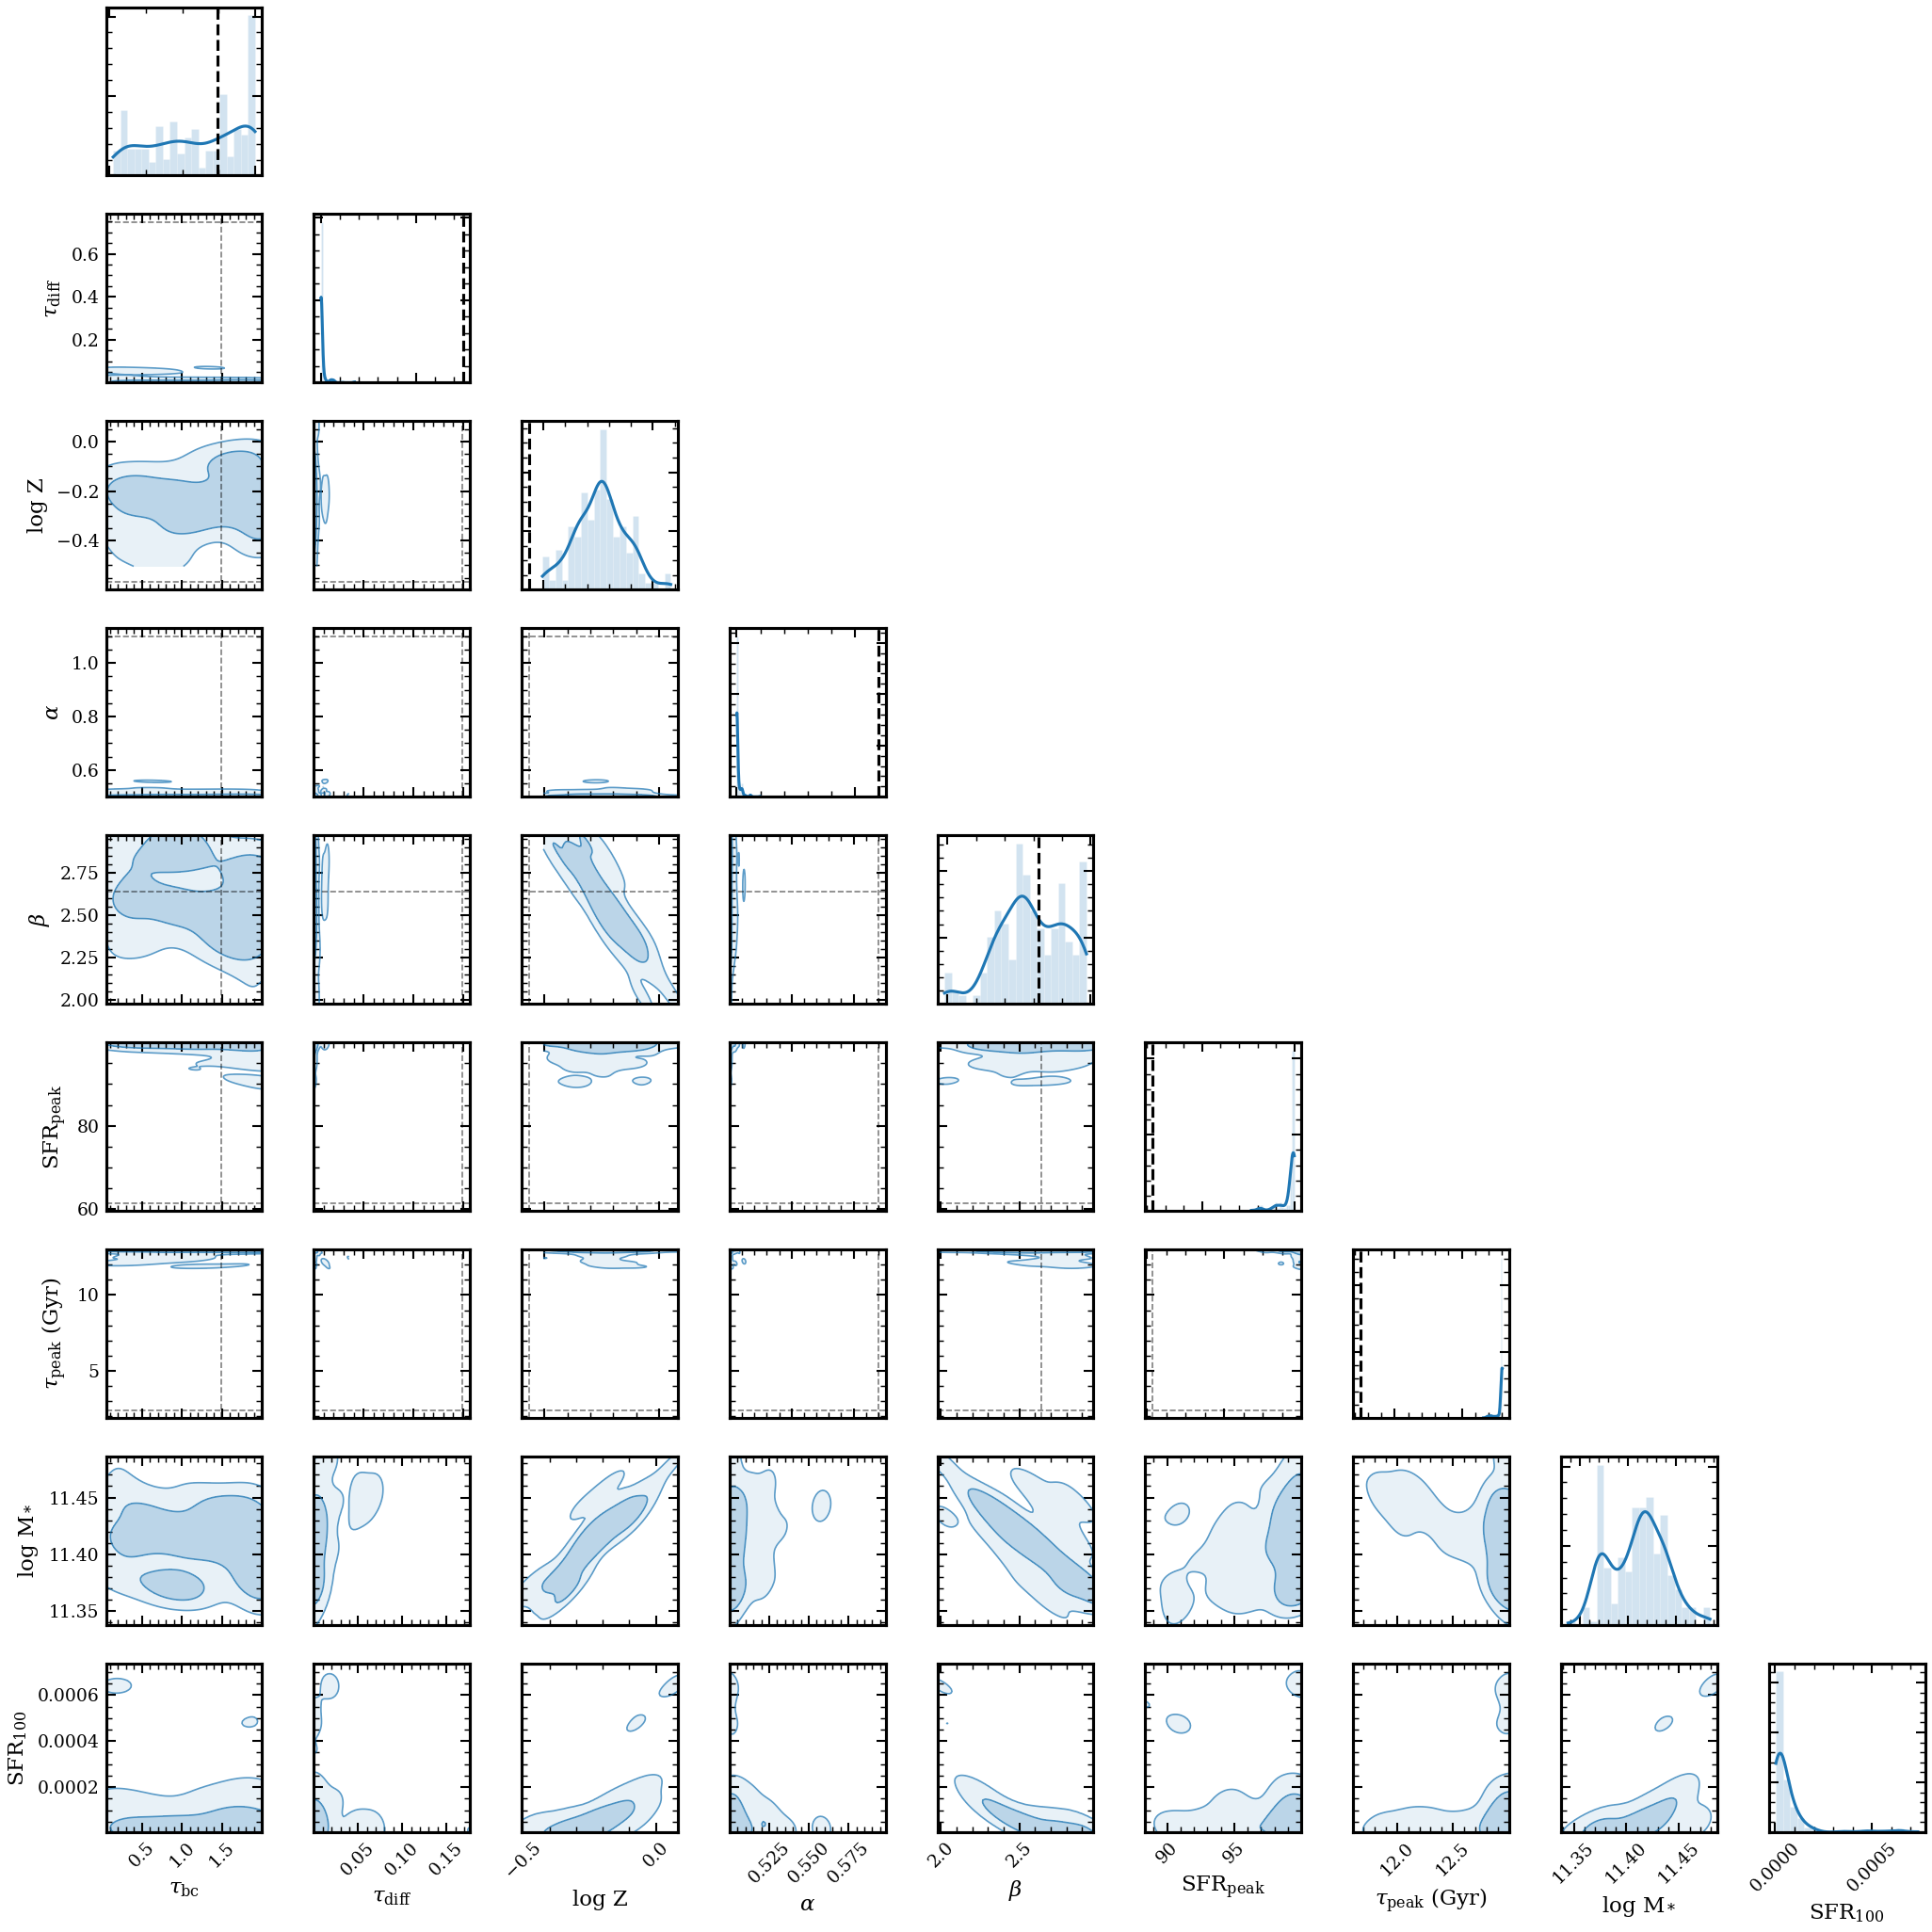

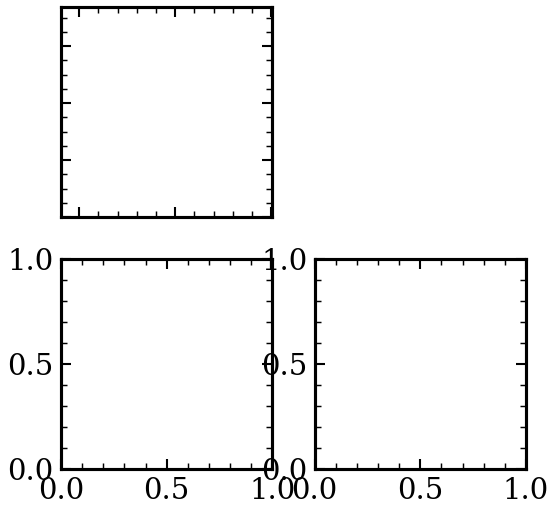

Parameter                Phot CI     Spec CI     Ratio
----------------------------------------------------
  dust_tau_bc               1.5551      0.0000       infx
  dust_tau_diff             0.0061      0.0000       infx
  met_logzsol               0.2272      0.0000       infx
  sfh_alpha                 0.0106      0.0000       infx
  sfh_beta                  0.4879      0.0000       infx
  sfh_peak_sfr              3.3170      0.0000       infx
  sfh_tau_peak_gyr          0.0656      0.0000       infx


In [5]:
# Overlay corner plots: photometry (blue) vs spectroscopy (orange)
fig_compare = safe_corner(result_rt_phot, truths=true_param, color="C0",
                          label="Photometry")
if fig_compare is not None:
    safe_corner(result_rt_spec, truths=true_param, color="C1",
                label="Spectroscopy", fig=fig_compare)
plt.show()

# --- 68% CI width comparison ---
print(f"{'Parameter':20s}  {'Phot CI':>10s}  {'Spec CI':>10s}  {'Ratio':>8s}")
print("-" * 52)
for name in spec_param.free_params:
    lo_p, hi_p = np.percentile(result_rt_phot.samples[name], [16, 84])
    lo_s, hi_s = np.percentile(result_rt_spec.samples[name], [16, 84])
    w_p = hi_p - lo_p
    w_s = hi_s - lo_s
    ratio = w_p / w_s if w_s > 0 else float("inf")
    print(f"  {name:20s}  {w_p:10.4f}  {w_s:10.4f}  {ratio:8.2f}x")

## Part B: Stochastic Model (137 free parameters)

This is the IFT model -- the unique contribution of **diffsed**.  The SFH
includes a Gaussian-process correlated field whose PSD is governed by two
physical hyper-parameters: $\sigma_{\rm PSD}$ (amplitude of stochastic
variability in dex) and $\tau_{\rm PSD}$ (correlation timescale in Myr).

We now need to recover **both** the SFH shape **and** the PSD parameters.

Free parameters: D = 9
  (physical: -119, GP latent: 128)
True PSD: sigma=1.5, tau=50 Myr


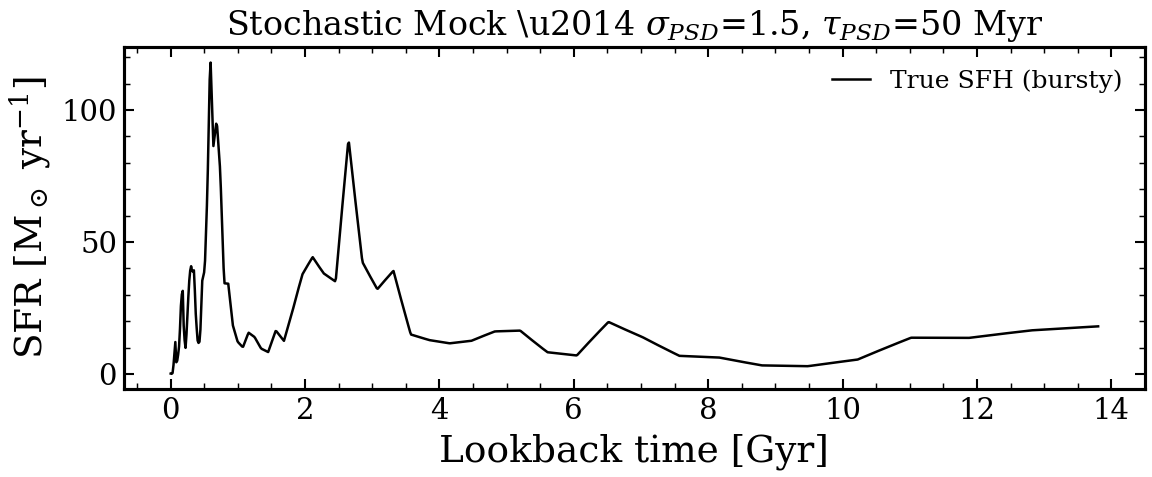

In [6]:
spec_stoch = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0),
    psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=128,
)

# Fix known PSD parameters for controlled test
key_stoch = jax.random.PRNGKey(7)
true_stoch = spec_stoch.sample(key_stoch)
# Override PSD params to known values for clear demonstration
true_stoch = {**true_stoch, "psd_sigma": 1.5, "psd_tau_myr": 50.0}

model_stoch = Model(spec_stoch, ssp_data, filters=filters)
mock_stoch = model_stoch.mock(true_stoch, snr=20.0, key=key_stoch)

D = spec_stoch.n_free
print(f"Free parameters: D = {D}")
print(f"  (physical: {D - 128}, GP latent: 128)")
print(f"True PSD: sigma={true_stoch['psd_sigma']:.1f}, tau={true_stoch['psd_tau_myr']:.0f} Myr")

# Plot the bursty SFH
fig, ax = plt.subplots(figsize=(8, 3.5))
sfh_true = model_stoch.predict_sfh(true_stoch)
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_full"], color="k", lw=1.2,
        label="True SFH (bursty)")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")
ax.set_title(f"Stochastic Mock \\u2014 $\\sigma_{{PSD}}$=1.5, $\\tau_{{PSD}}$=50 Myr")
ax.legend()
plt.tight_layout()
plt.show()

  Step     0/500: loss = 771.3431
  Step   200/500: loss = 4.3921
  Step   400/500: loss = 2.9117
  Step   499/500: loss = 2.5132
  MAP (ADAM) complete in 0.2s, 500 steps
MAP finished in 0.3s
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
OPTIMIZE_KL: Starting 0001


  Ray Tracing complete in 0.4s. Acceptance: 99.0% (overall), 99.7% (post burn-in). Samples: 300
Ray Tracing finished in 0.7s (9-D)
geoVI: 137 params, 5 data points, 10 iterations


...

MCG: Iteration 6 ⛰:-7.5432e-09 Δ⛰:1.6561e-09 ➽:9.3049e-09 |∇|:2.7137e-03 ➽:1.3129e-04


M: →:1.0 ↺:False #∇²:118 |↘|:6.152199e-04 🞋:1.370000e-03
M: Iteration 18 ⛰:+7.537608e+01 Δ⛰:8.758022e-09


OPTIMIZE_KL: Iteration 0010 ⛰:+7.5376e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (5, 5, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4)
OPTIMIZE_KL: #(KL minimization steps) 18
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:    0.47±    0.24, avg:   +0.022±    0.11, #dof:      5'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     1.3±    0.73, avg:   -0.043±     1.2, #dof:      1'
dust_tau_diff           :: 'reduced χ²:     2.8±     2.2, avg:     -1.5±    0.66, #dof:      1'
met_logzsol             :: 'reduced χ²:     1.9±     1.8, avg:     -1.1±    0.77, #dof:      1'
psd_sigma               :: 'reduced χ²:     1.3±     1.8, avg:    +0.13±     1.1, #dof:      1'
psd_tau_myr             :: 'reduced χ²:    0.64±     0.7, avg:    +0.36±    0.71, #dof:      1'
psd_xi                  :: 'reduced χ²:     1.0±    0.17, avg:    +0.14±   0.048, #dof:    128'
sfh_alpha               :: 'reduced χ²:     1.4±     1.1, avg:    +0.09±     1.2, #dof:      1'
sfh_beta                :: '

  Drawing 100 posterior samples...


  geoVI complete in 80.5s, 112 posterior samples
geoVI finished in 80.7s (9-D)


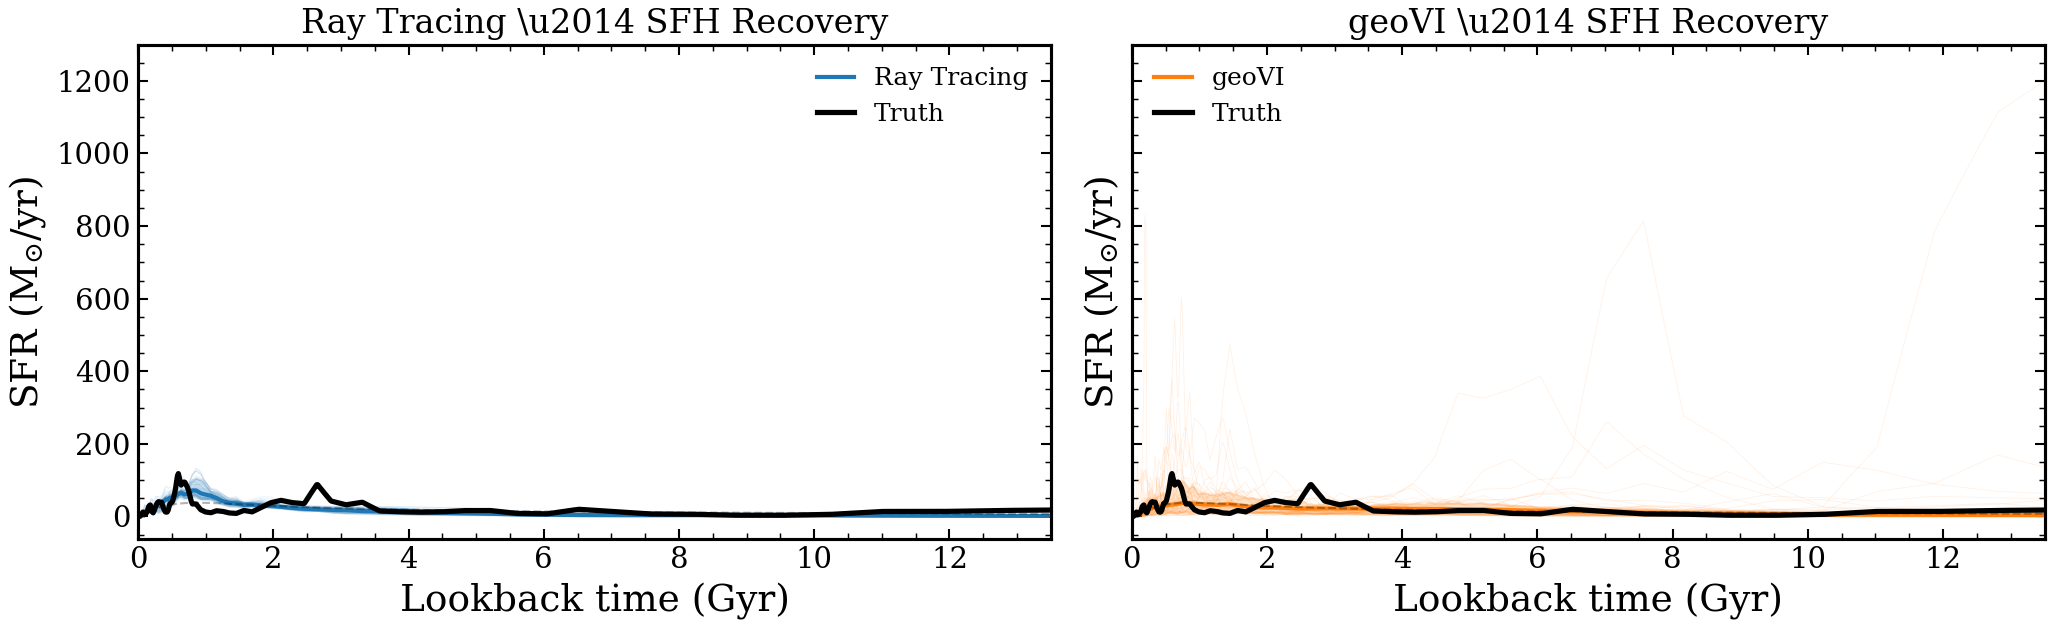

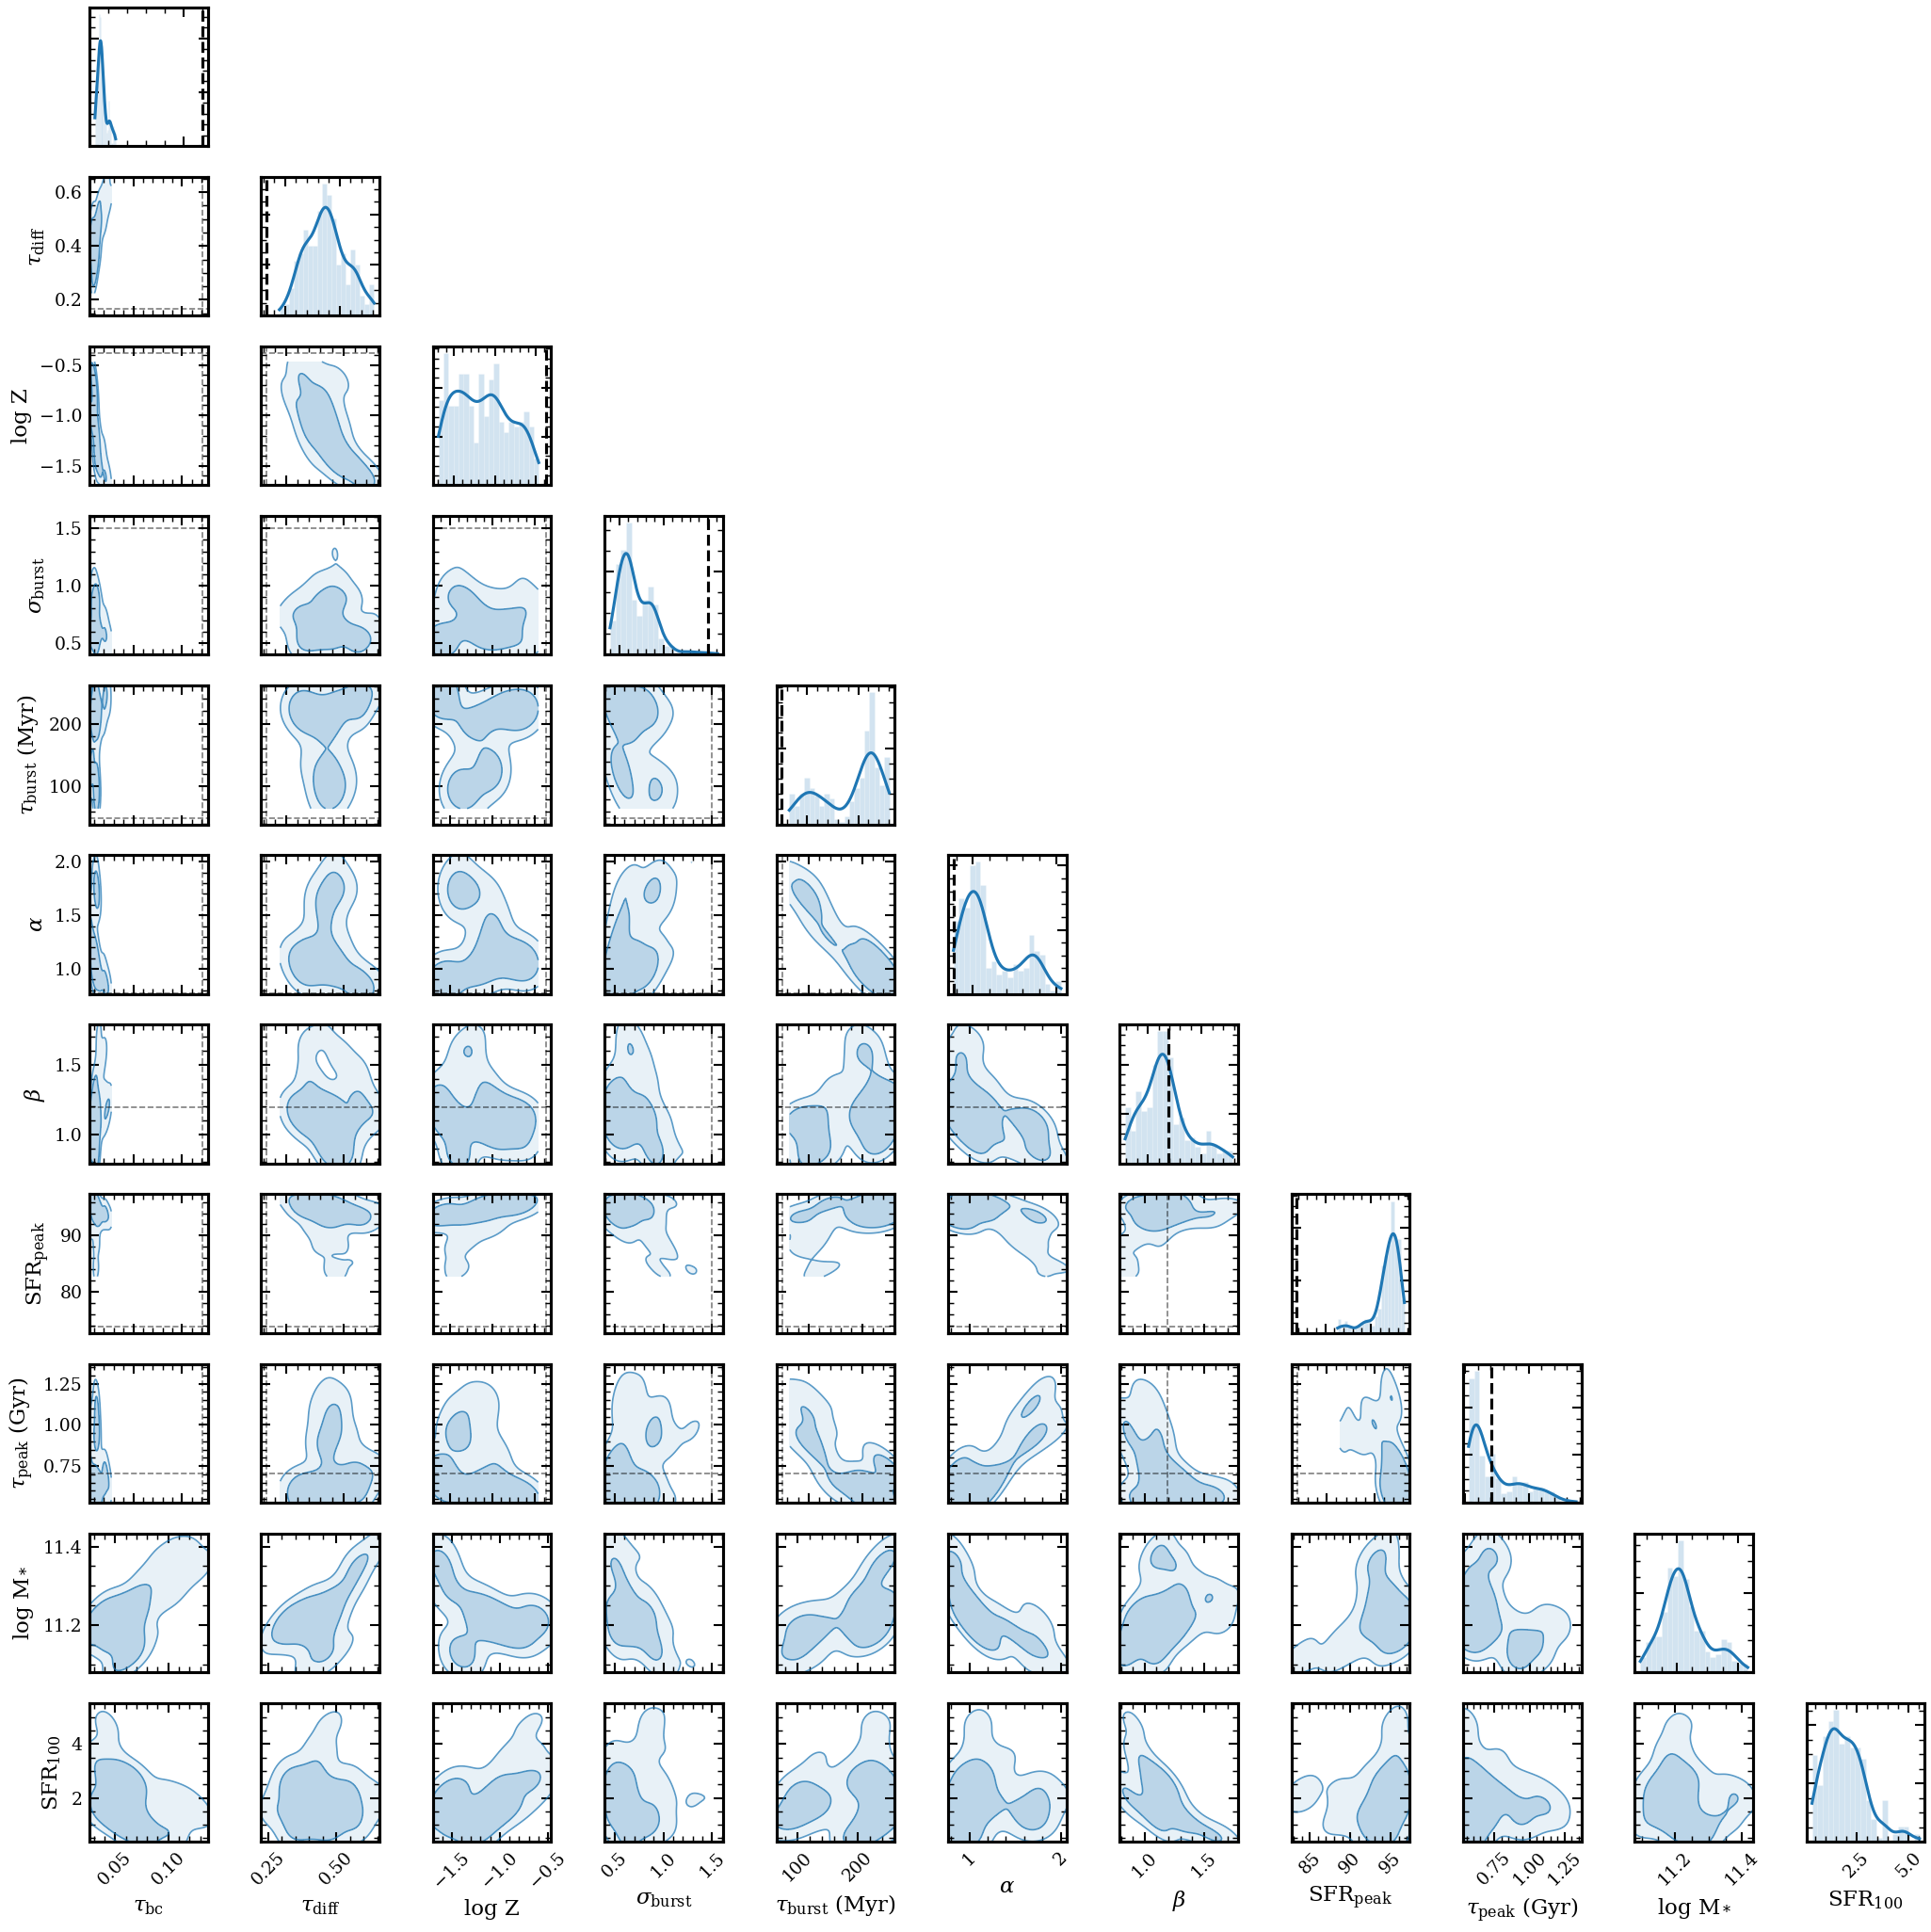

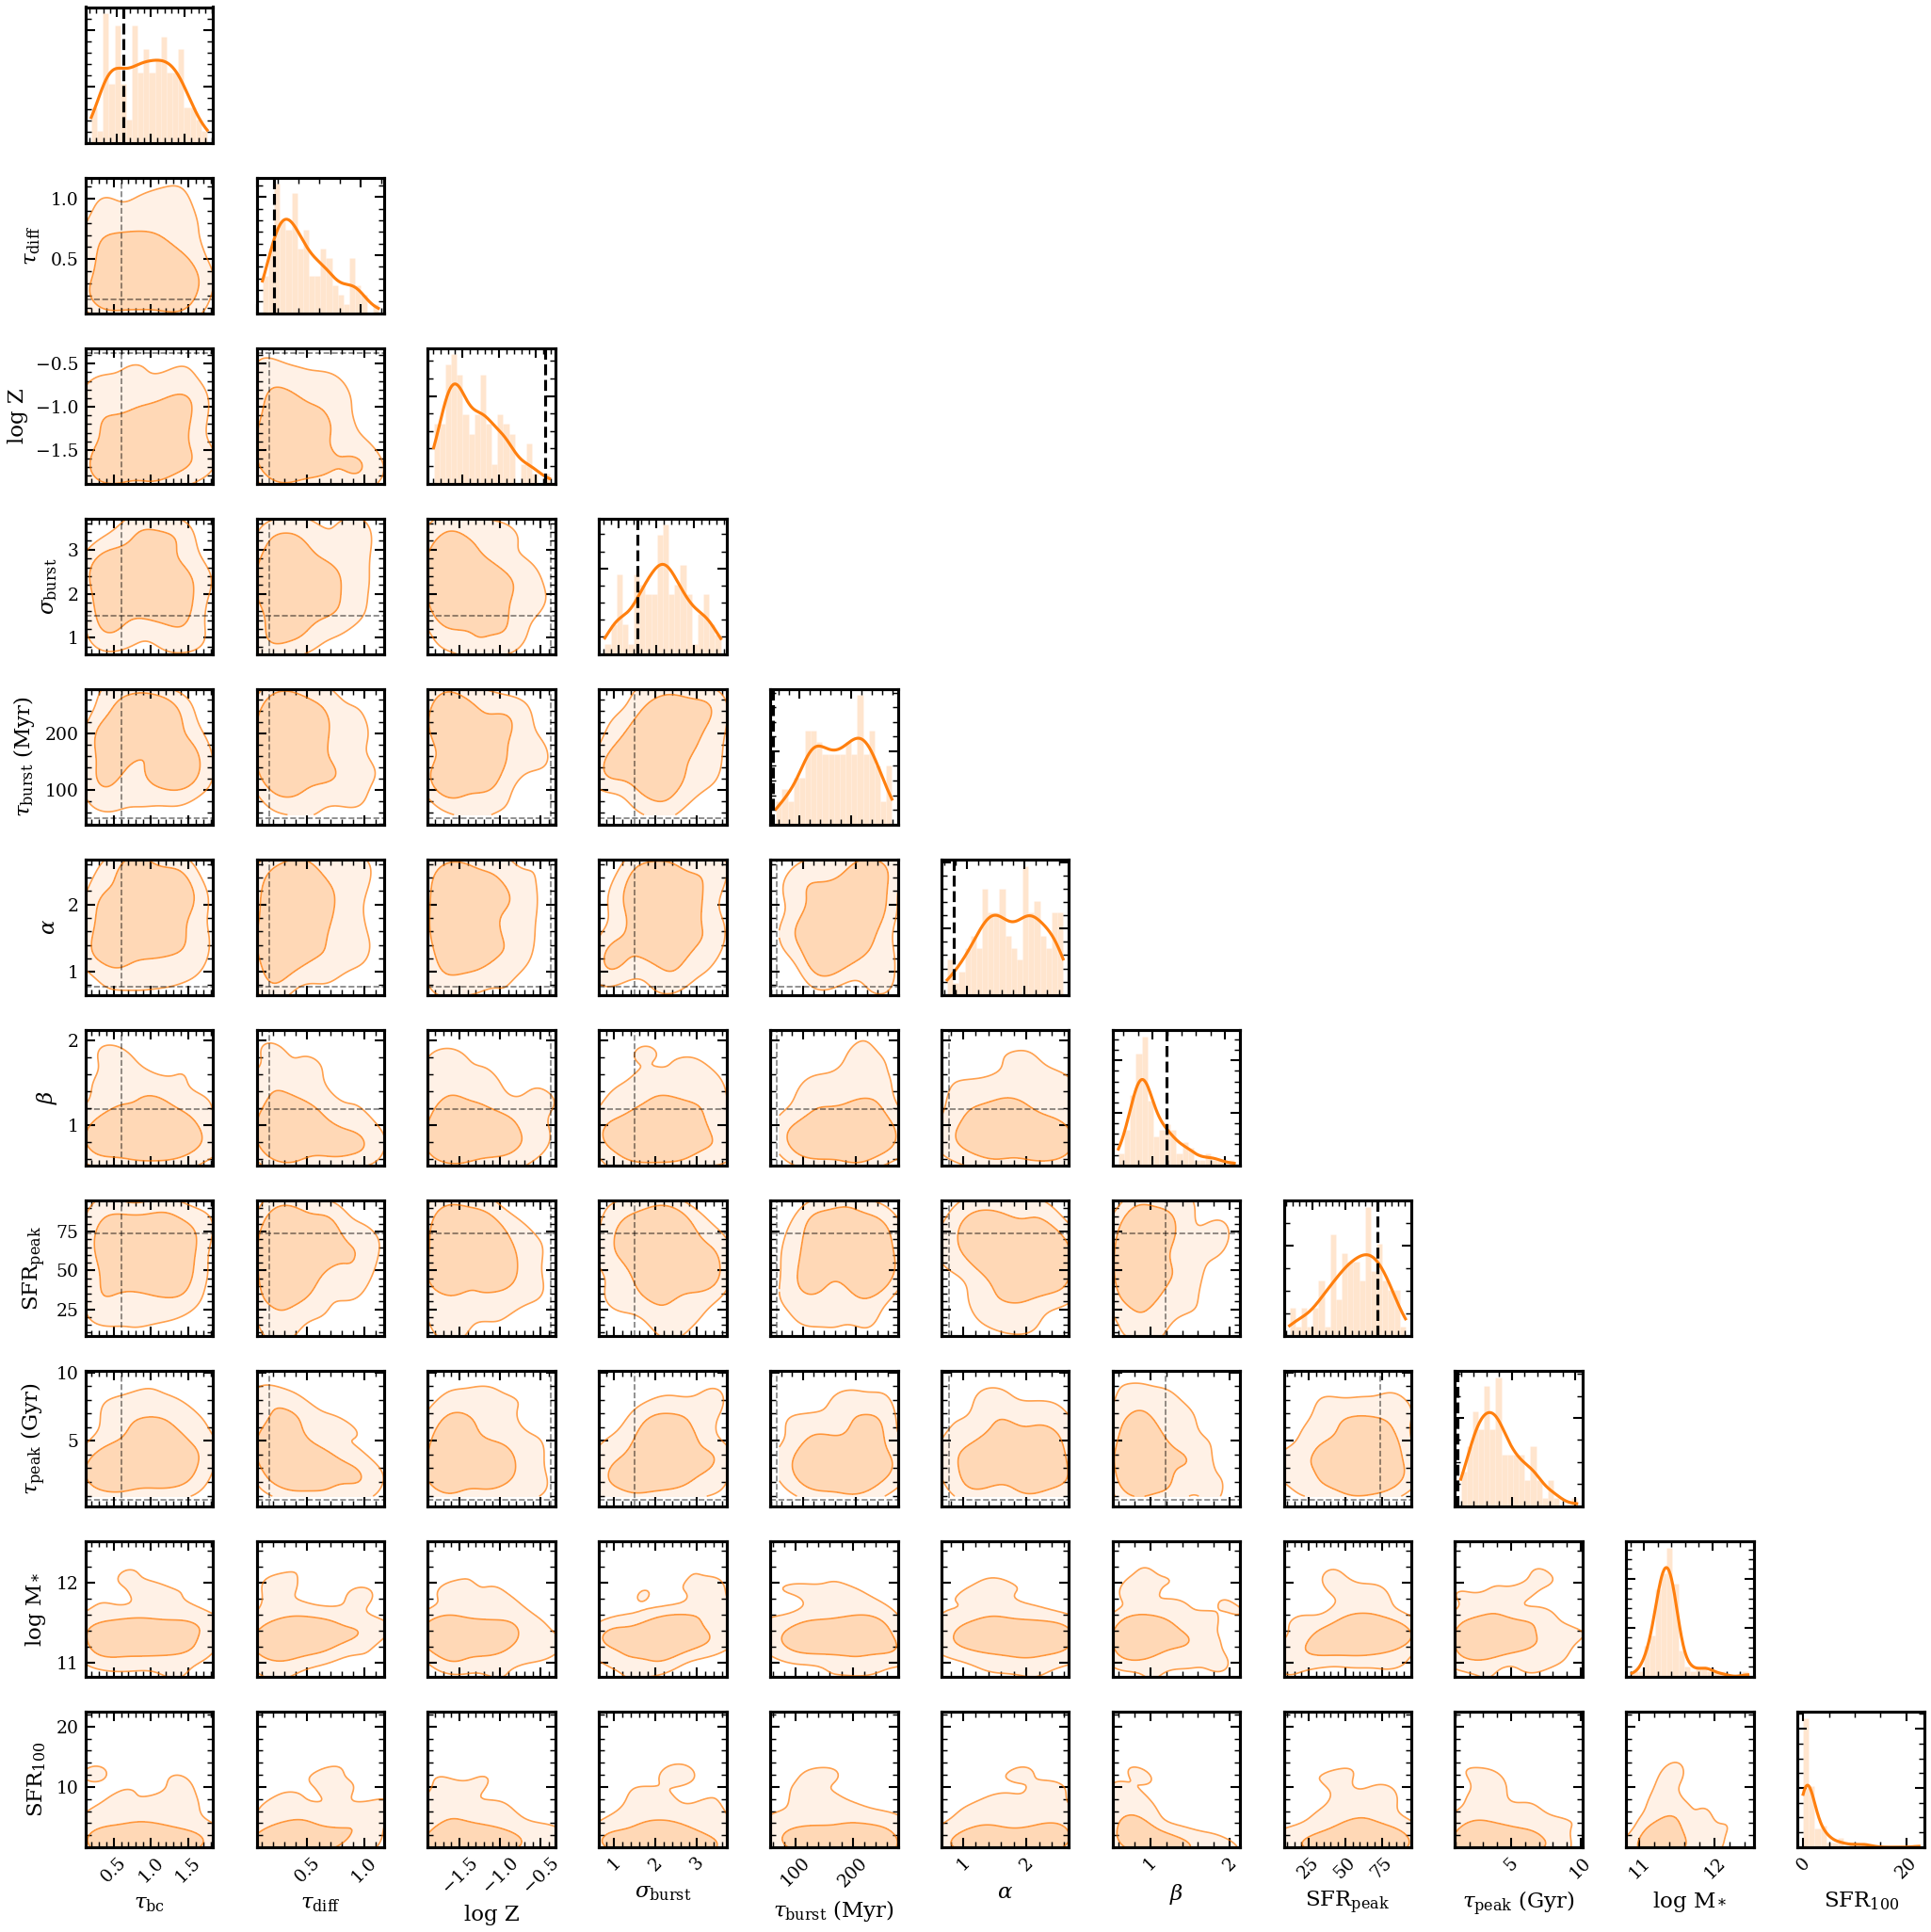

In [7]:
fitter_stoch = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise,
                      data_type="photometry")

# MAP initialisation
t0 = time.perf_counter()
result_map_stoch = fitter_stoch.run("map", n_steps=500)
print(f"MAP finished in {time.perf_counter() - t0:.1f}s")

# Ray Tracing
t0 = time.perf_counter()
result_rt = fitter_stoch.run("raytrace", init_from=result_map_stoch,
                             n_burnin=100, n_steps=300, step_size=0.01)
t_rt = time.perf_counter() - t0
print(f"Ray Tracing finished in {t_rt:.1f}s ({D}-D)")

# geoVI
t0 = time.perf_counter()
result_geovi = fitter_stoch.run("geovi", init_from=result_map_stoch,
                                n_iterations=10, n_samples=6)
t_geovi = time.perf_counter() - t0
print(f"geoVI finished in {t_geovi:.1f}s ({D}-D)")

# --- Side-by-side SFH recovery ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

model_stoch.plot_sfh_posterior(result_rt, true_params=true_stoch,
                              color="C0", label="Ray Tracing", ax=axes[0])
axes[0].set_title("Ray Tracing \\u2014 SFH Recovery")
axes[0].legend()

model_stoch.plot_sfh_posterior(result_geovi, true_params=true_stoch,
                              color="C1", label="geoVI", ax=axes[1])
axes[1].set_title("geoVI \\u2014 SFH Recovery")
axes[1].legend()

plt.tight_layout()
plt.show()

# Corner overlay (physical params only)
fig_corner_stoch = safe_corner(result_rt, truths=true_stoch, color="C0",
                               label="Ray Tracing")
if fig_corner_stoch is not None:
    safe_corner(result_geovi, truths=true_stoch, color="C1",
                label="geoVI", fig=fig_corner_stoch)
plt.show()

### Can We Recover PSD Parameters from a Single Galaxy?

The PSD amplitude $\sigma_{\rm PSD}$ is typically well-constrained
because the *scatter* in the SFH is directly visible in the integrated
photometry.  The PSD timescale $\tau_{\rm PSD}$, however, is poorly
constrained: changing the correlation length while holding the variance
fixed produces similar broadband colours.

**This degeneracy motivates hierarchical inference** (Tutorial 05), where
$\tau_{\rm PSD}$ is shared across a population of galaxies and can be
constrained by the ensemble.

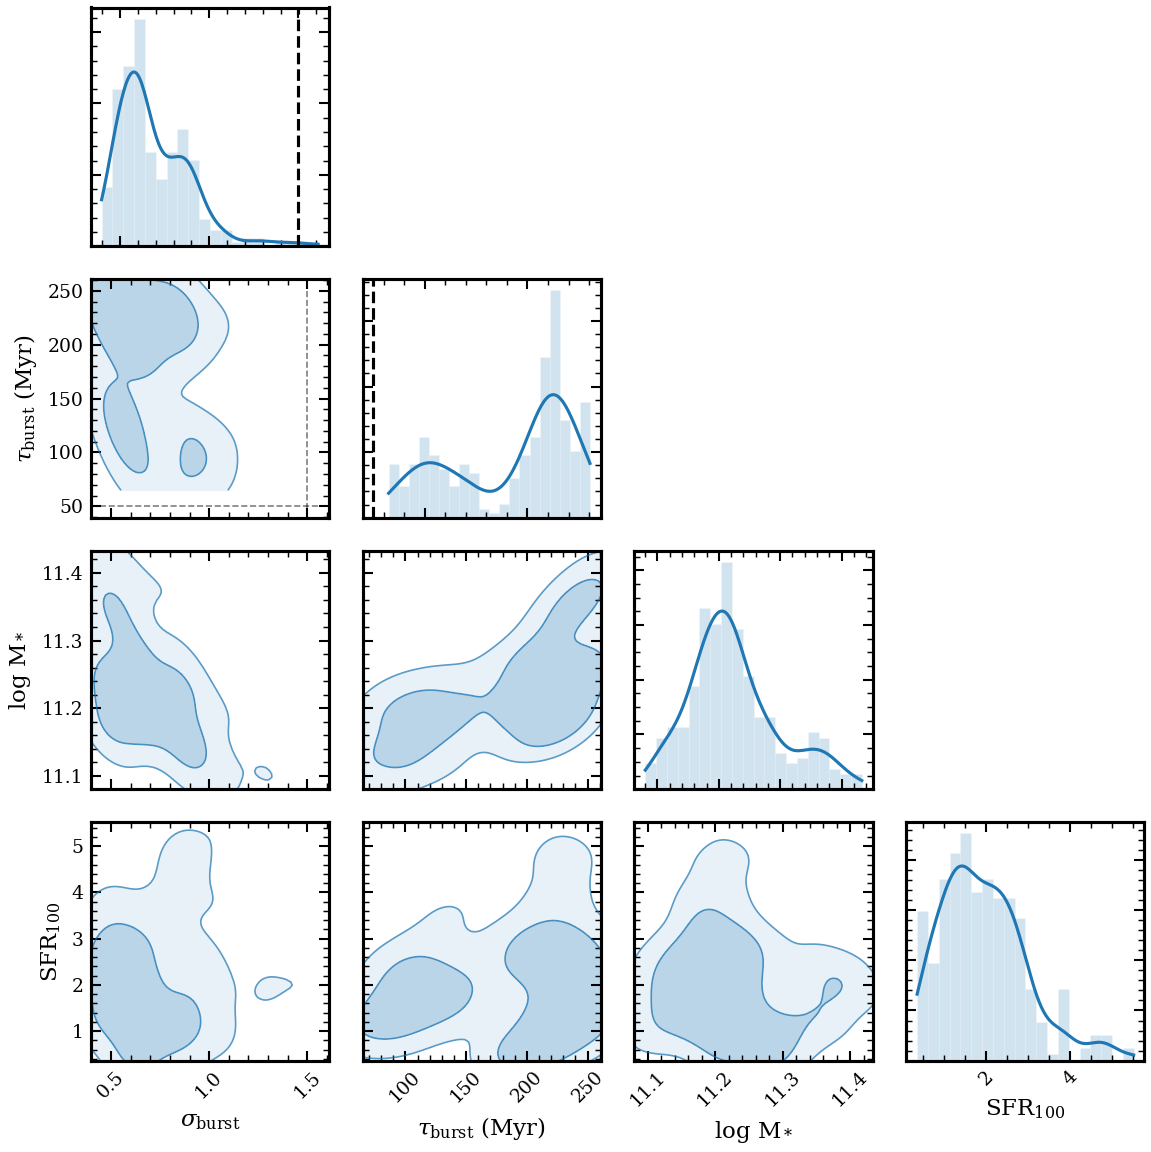

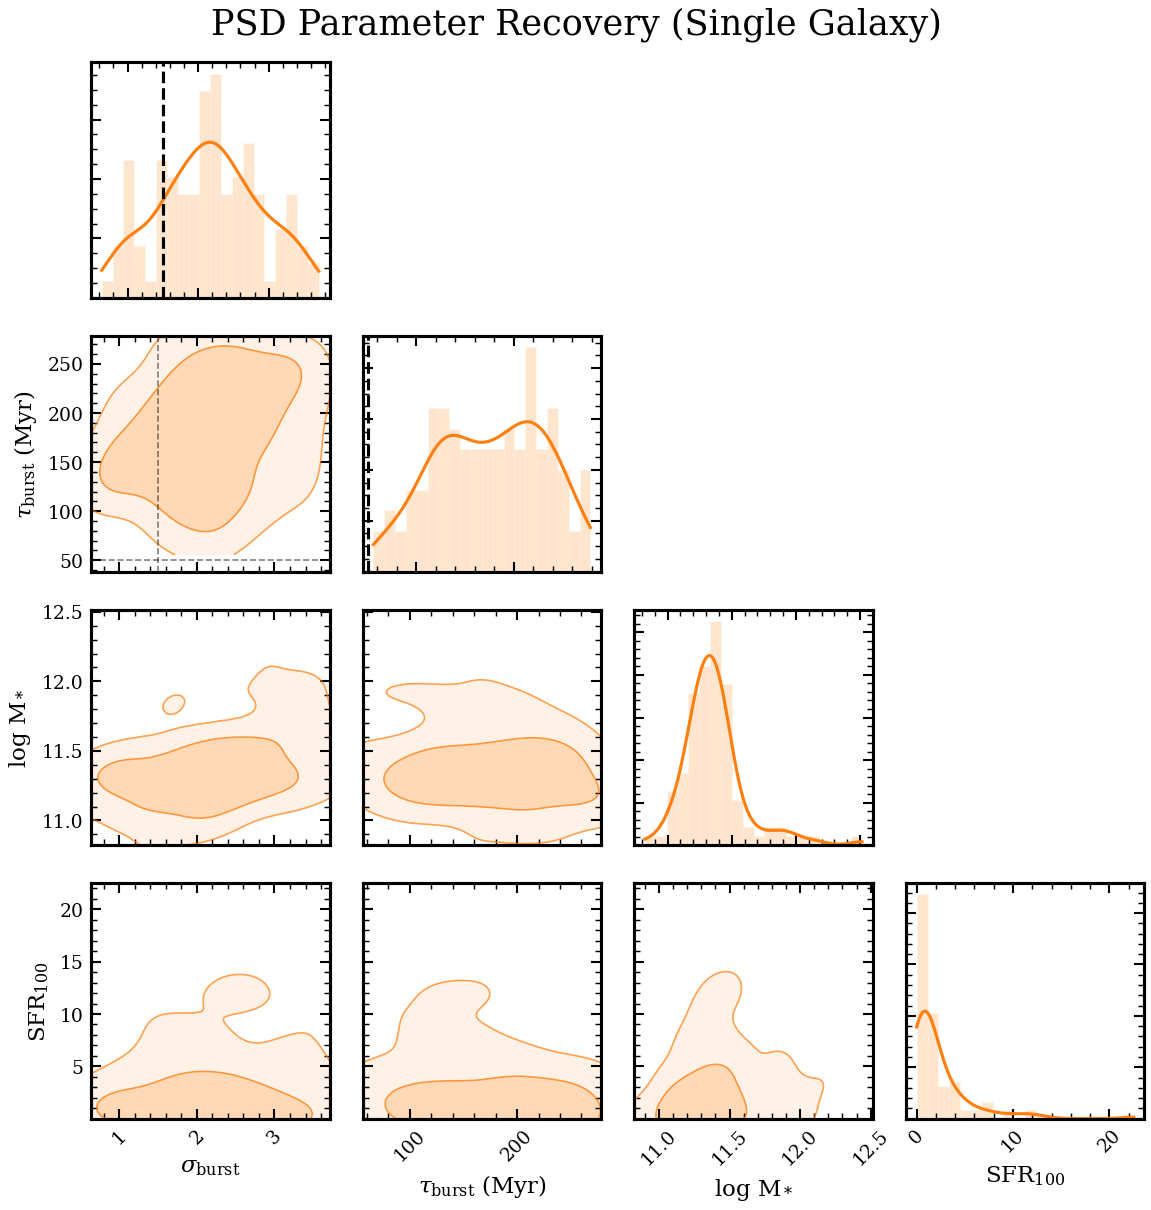

  psd_sigma      : truth=1.50  RT=0.63 [0.50, 0.88]  CI width=0.38
  psd_tau_myr    : truth=50.00  RT=211.92 [103.49, 236.11]  CI width=132.61


In [8]:
# Extract PSD parameter samples for focused corner plot
psd_names = ["psd_sigma", "psd_tau_myr"]
psd_truths = {k: true_stoch[k] for k in psd_names}

fig_psd = safe_corner(result_rt, params=psd_names, truths=psd_truths,
                      color="C0", label="Ray Tracing")
if fig_psd is not None:
    safe_corner(result_geovi, params=psd_names, truths=psd_truths,
                color="C1", label="geoVI", fig=fig_psd)
plt.suptitle("PSD Parameter Recovery (Single Galaxy)", y=1.02)
plt.show()

# Quantify
for name in psd_names:
    lo_rt, med_rt, hi_rt = np.percentile(result_rt.samples[name], [16, 50, 84])
    truth = float(psd_truths[name])
    print(f"  {name:15s}: truth={truth:.2f}  "
          f"RT={med_rt:.2f} [{lo_rt:.2f}, {hi_rt:.2f}]  "
          f"CI width={hi_rt - lo_rt:.2f}")

### Recovery Across Burstiness Regimes

How does recovery quality depend on the true PSD parameters?  We test
four regimes spanning the range from smooth to highly bursty:

| Regime | $\sigma_{\rm PSD}$ | $\tau_{\rm PSD}$ [Myr] | Expected behaviour |
|--------|---------------------|-------------------------|--------------------|
| Smooth | 0.5 | 200 | Near-parametric; easy to recover |
| Moderate | 1.0 | 50 | Mild stochasticity; good recovery |
| Bursty | 2.0 | 20 | Strong bursts; SFH recovered, PSD partly |
| Extreme | 3.0 | 5 | Very rapid bursts; challenging |

  Step     0/500: loss = 496.7696


  Step   200/500: loss = 1.9989
  Step   400/500: loss = 1.7064
  Step   499/500: loss = 1.5968
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.3% (overall), 99.4% (post burn-in). Samples: 150


  Step     0/500: loss = 671.3403
  Step   200/500: loss = 6.0690
  Step   400/500: loss = 5.3861
  Step   499/500: loss = 5.2221
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 98.6% (overall), 98.5% (post burn-in). Samples: 150


  Step     0/500: loss = 725.5160
  Step   200/500: loss = 2.8050
  Step   400/500: loss = 2.3317
  Step   499/500: loss = 2.2143
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.2% (overall), 99.3% (post burn-in). Samples: 150


  Step     0/500: loss = 844.0779
  Step   200/500: loss = 2.3880
  Step   400/500: loss = 1.9299
  Step   499/500: loss = 1.8121
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 98.9% (overall), 98.8% (post burn-in). Samples: 150


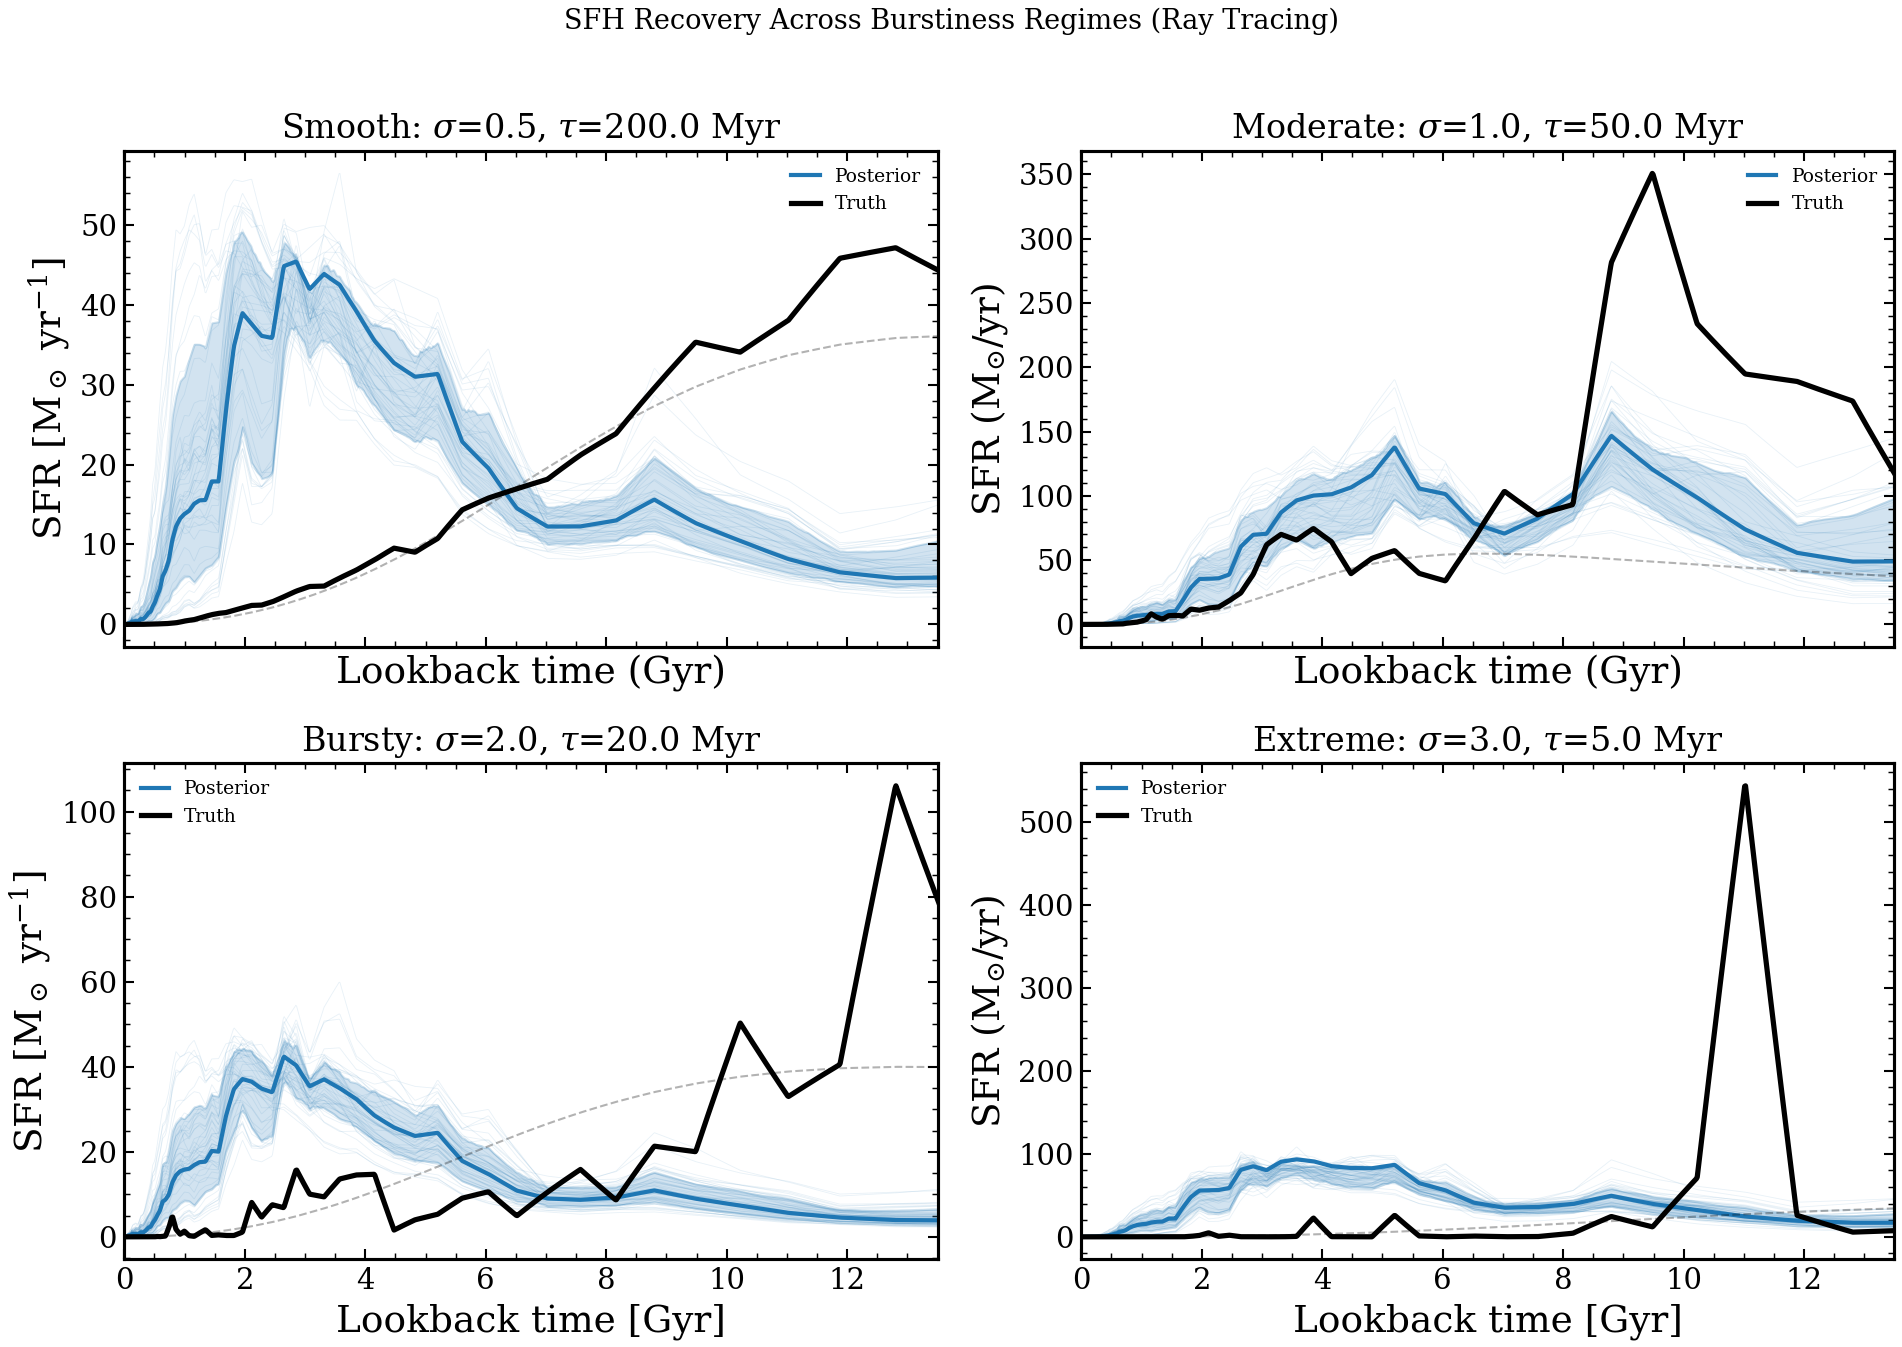

In [9]:
regimes = [
    ("Smooth",   0.5, 200.0),
    ("Moderate",  1.0,  50.0),
    ("Bursty",    2.0,  20.0),
    ("Extreme",   3.0,   5.0),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes_flat = axes.ravel()

for i, (label, sigma, tau) in enumerate(regimes):
    key_i = jax.random.PRNGKey(100 + i)

    # Sample and override PSD params
    true_i = spec_stoch.sample(key_i)
    true_i = {**true_i, "psd_sigma": sigma, "psd_tau_myr": tau}

    mock_i = model_stoch.mock(true_i, snr=20.0, key=key_i)

    # MAP + RT (fast settings for survey)
    fitter_i = Fitter(model_stoch, mock_i.flux_obs, mock_i.noise,
                      data_type="photometry")
    map_i = fitter_i.run("map", n_steps=500)
    rt_i = fitter_i.run("raytrace", init_from=map_i,
                        n_burnin=50, n_steps=150, step_size=0.01)

    # Plot SFH recovery
    ax = axes_flat[i]
    model_stoch.plot_sfh_posterior(rt_i, true_params=true_i,
                                  color="C0", ax=ax)
    ax.set_title(f"{label}: $\\sigma$={sigma}, $\\tau$={tau} Myr")
    if i >= 2:
        ax.set_xlabel("Lookback time [Gyr]")
    if i % 2 == 0:
        ax.set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")

plt.suptitle("SFH Recovery Across Burstiness Regimes (Ray Tracing)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### What Happens When You Fit with the Wrong Model?

A critical test: fit a **bursty** mock (generated with the stochastic
model) using the **parametric-only** model.  The smooth model cannot
capture recent bursts, leading to **systematic bias** in derived
quantities -- particularly recent SFR and sSFR.

  Step     0/500: loss = 250.0548
  Step   200/500: loss = 8.2093
  Step   400/500: loss = 2.0060
  Step   499/500: loss = 1.5240
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 7 params, 100 burn-in + 200 samples, 10 leapfrog/step, step_size=0.0794


  Ray Tracing complete in 0.3s. Acceptance: 25.7% (overall), 26.9% (post burn-in). Samples: 200
  Step     0/500: loss = 261.2695
  Step   200/500: loss = 3.0609


  Step   400/500: loss = 2.6397
  Step   499/500: loss = 2.5070
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.8s. Acceptance: 99.5% (overall), 99.7% (post burn-in). Samples: 300


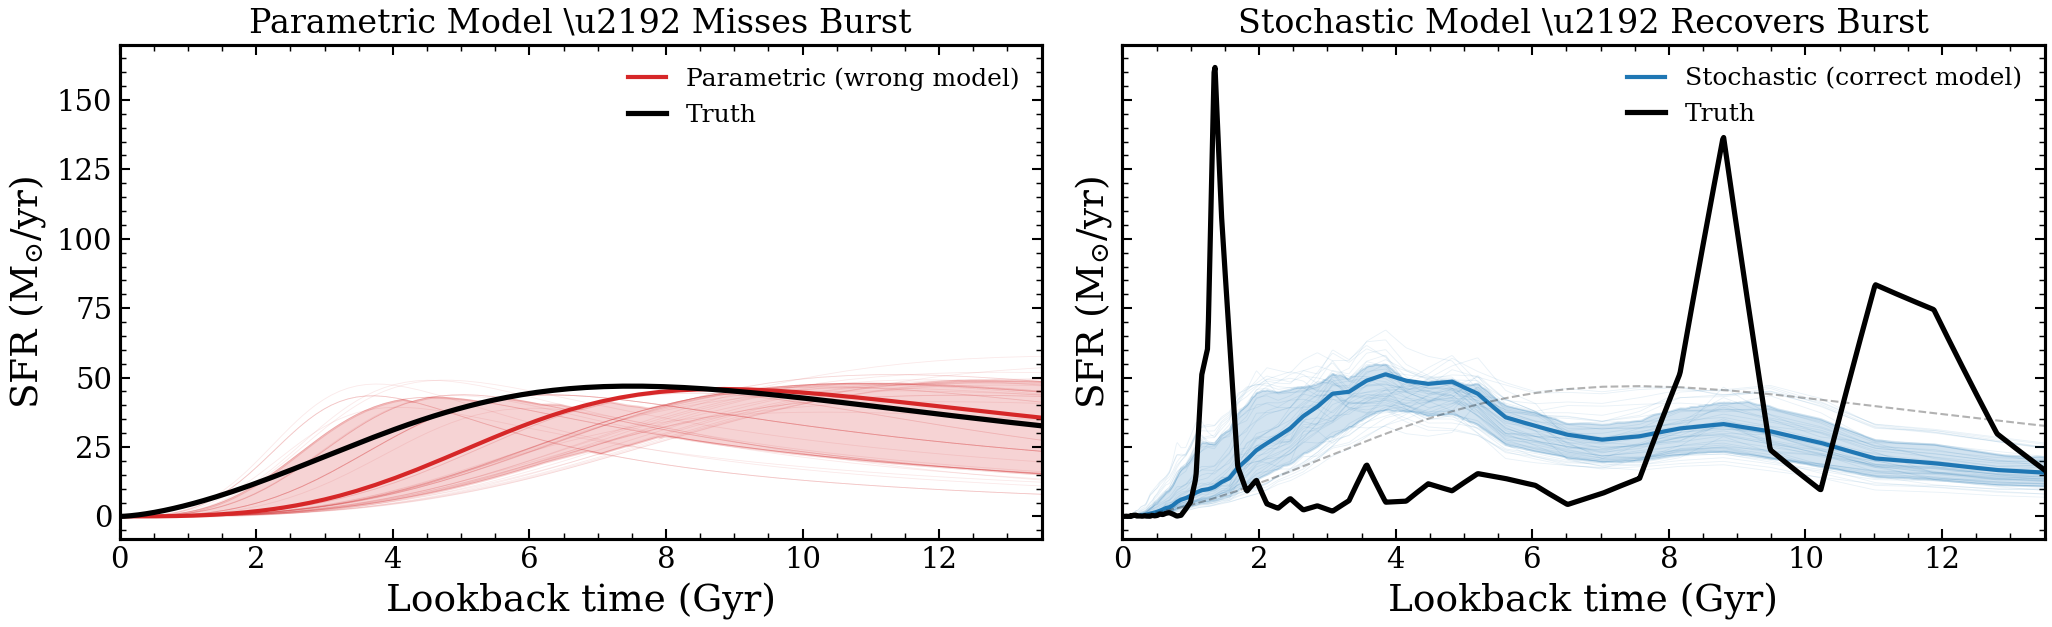

Derived quantity comparison (bursty mock):
Quantity                     Truth      Parametric      Stochastic
----------------------------------------------------------------
  stellar_mass                   nan       3.259e+11       3.571e+11
  sfr_100myr                     nan       1.497e-05         0.00534
  sfr_10myr                      nan       3.104e-08       5.228e-05
  ssfr                           nan       4.477e-17       1.441e-14


In [10]:
# Generate a bursty mock
key_mm = jax.random.PRNGKey(2024)
true_bursty = spec_stoch.sample(key_mm)
true_bursty = {**true_bursty, "psd_sigma": 2.0, "psd_tau_myr": 20.0}
mock_bursty = model_stoch.mock(true_bursty, snr=20.0, key=key_mm)

# Fit with parametric (wrong!) model
fitter_wrong = Fitter(model_param, mock_bursty.flux_obs, mock_bursty.noise,
                      data_type="photometry")
map_wrong = fitter_wrong.run("map", n_steps=500)
rt_wrong = fitter_wrong.run("raytrace", init_from=map_wrong,
                              n_burnin=100, n_steps=200)

# Fit with stochastic (correct) model
fitter_right = Fitter(model_stoch, mock_bursty.flux_obs, mock_bursty.noise,
                      data_type="photometry")
map_right = fitter_right.run("map", n_steps=500)
rt_right = fitter_right.run("raytrace", init_from=map_right,
                            n_burnin=100, n_steps=300, step_size=0.01)

# Compare SFH recovery
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

model_param.plot_sfh_posterior(rt_wrong, true_params=true_bursty,
                              color="C3", label="Parametric (wrong model)",
                              ax=axes[0])
axes[0].set_title("Parametric Model \\u2192 Misses Burst")
axes[0].legend()

model_stoch.plot_sfh_posterior(rt_right, true_params=true_bursty,
                              color="C0", label="Stochastic (correct model)",
                              ax=axes[1])
axes[1].set_title("Stochastic Model \\u2192 Recovers Burst")
axes[1].legend()

plt.tight_layout()
plt.show()

# Compare derived quantities
derived_wrong = rt_wrong.derived
derived_right = rt_right.derived
sfh_truth = model_stoch.predict_sfh(true_bursty)

print("Derived quantity comparison (bursty mock):")
print(f"{'Quantity':20s}  {'Truth':>12s}  {'Parametric':>14s}  {'Stochastic':>14s}")
print("-" * 64)
for qty in ["stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr"]:
    truth_val = float(sfh_truth.get(qty, np.nan))
    med_w = float(np.median(derived_wrong[qty]))
    med_r = float(np.median(derived_right[qty]))
    print(f"  {qty:20s}  {truth_val:12.4g}  {med_w:14.4g}  {med_r:14.4g}")

## Part C: Robustness

### SNR Dependence

How do posteriors change with data quality?  We fit the same stochastic
galaxy at four signal-to-noise levels: SNR = 5, 10, 20, 50.  As expected,
posteriors widen at low SNR and tighten at high SNR.  The key question is
whether the truth remains within the credible intervals across all regimes.

  Step     0/500: loss = 64.1430


  Step   200/500: loss = 1.6725
  Step   400/500: loss = 1.1665
  Step   499/500: loss = 1.0367
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 100.0% (overall), 100.0% (post burn-in). Samples: 150


  Step     0/500: loss = 217.7560
  Step   200/500: loss = 2.8428
  Step   400/500: loss = 2.0419
  Step   499/500: loss = 1.8505
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.8% (overall), 99.8% (post burn-in). Samples: 150


  Step     0/500: loss = 760.9579
  Step   200/500: loss = 4.9584
  Step   400/500: loss = 3.6664
  Step   499/500: loss = 3.3370
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.1% (overall), 99.2% (post burn-in). Samples: 150


  Step     0/500: loss = 5421.8012
  Step   200/500: loss = 8.7678
  Step   400/500: loss = 7.3453
  Step   499/500: loss = 6.8424
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 150 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 91.4% (overall), 90.8% (post burn-in). Samples: 150


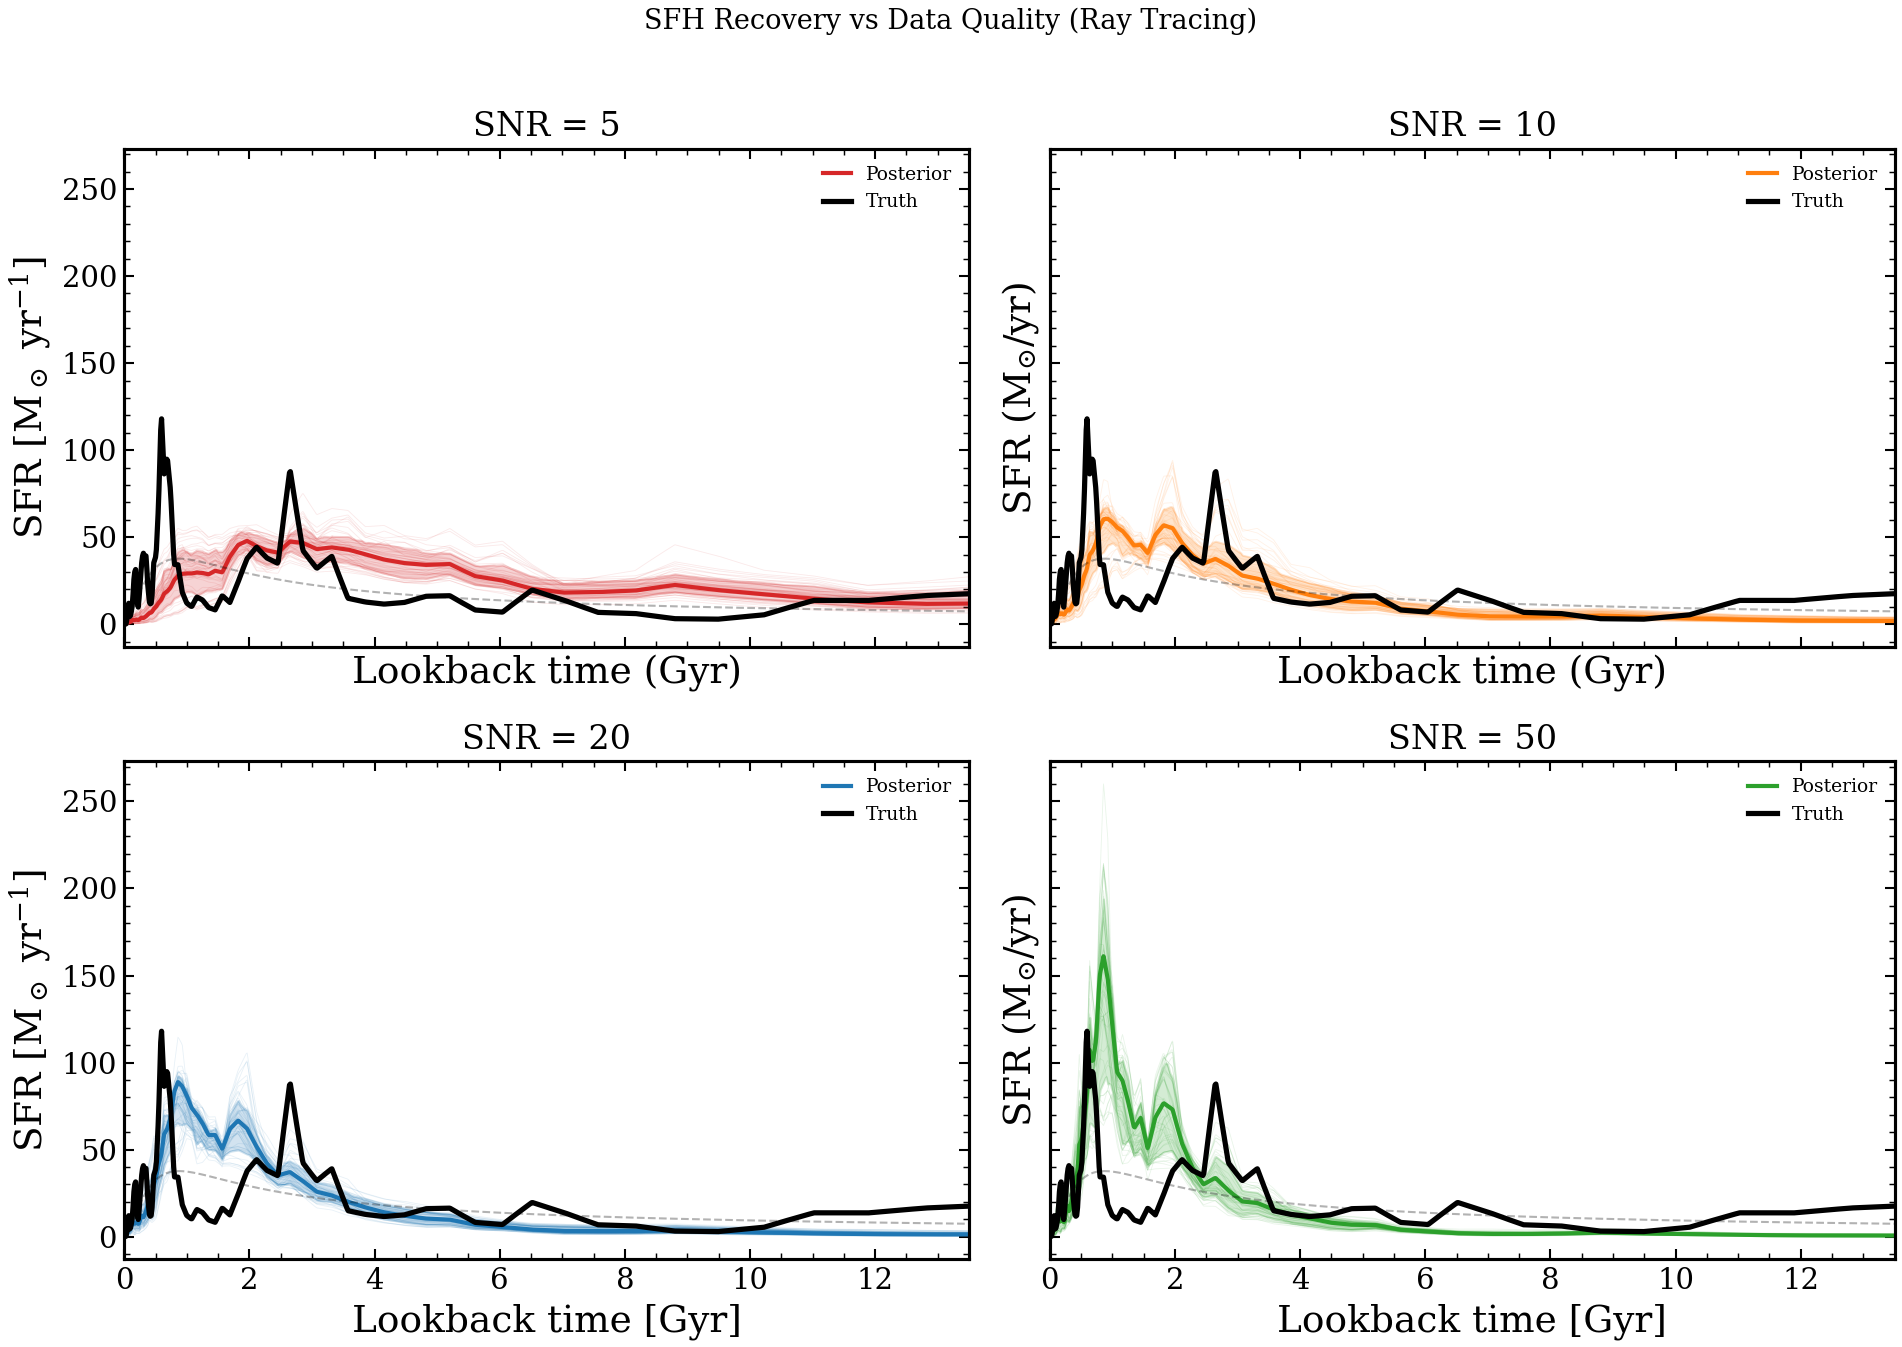

In [11]:
snr_values = [5, 10, 20, 50]
colors_snr = ["C3", "C1", "C0", "C2"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes_flat = axes.ravel()

for i, snr in enumerate(snr_values):
    key_snr = jax.random.PRNGKey(300 + i)
    mock_snr = model_stoch.mock(true_stoch, snr=float(snr), key=key_snr)

    fitter_snr = Fitter(model_stoch, mock_snr.flux_obs, mock_snr.noise,
                        data_type="photometry")
    map_snr = fitter_snr.run("map", n_steps=500)
    rt_snr = fitter_snr.run("raytrace", init_from=map_snr,
                            n_burnin=50, n_steps=150, step_size=0.01)

    ax = axes_flat[i]
    model_stoch.plot_sfh_posterior(rt_snr, true_params=true_stoch,
                                  color=colors_snr[i], ax=ax)
    ax.set_title(f"SNR = {snr}")
    if i >= 2:
        ax.set_xlabel("Lookback time [Gyr]")
    if i % 2 == 0:
        ax.set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")

plt.suptitle("SFH Recovery vs Data Quality (Ray Tracing)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Derived Quantities

Astronomers rarely use the raw SFH parameters directly.  Instead, they
work with **derived quantities**: stellar mass $M_*$, star formation rate
averaged over recent windows (SFR$_{100}$, SFR$_{10}$), and specific
star formation rate sSFR $= $ SFR$/M_*$.

How well are these recovered?  We compare truth vs. recovered (median
$\pm$ 68\% CI) for both the parametric and stochastic models.

In [12]:
def derived_summary(result, model, true_params, label):
    """Print derived quantity recovery table."""
    derived = result.derived
    sfh_truth = model.predict_sfh(true_params)

    print(f"\\n{label}")
    print(f"{'Quantity':20s}  {'Truth':>12s}  {'Median':>12s}  "
          f"{'68% CI':>20s}  {'Covered':>8s}")
    print("-" * 78)
    for qty in ["stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr"]:
        truth_val = float(sfh_truth.get(qty, np.nan))
        samples_qty = derived[qty]
        lo, med, hi = np.percentile(samples_qty, [16, 50, 84])
        covered = "OK" if lo <= truth_val <= hi else "MISS"
        print(f"  {qty:20s}  {truth_val:12.4g}  {med:12.4g}  "
              f"[{lo:9.4g}, {hi:9.4g}]  {covered:>8s}")

# Parametric model
derived_summary(result_rt_phot, model_param, true_param,
                "Parametric Model (NUTS, photometry)")

# Stochastic model
derived_summary(result_rt, model_stoch, true_stoch,
                "Stochastic Model (Ray Tracing, photometry)")

\nParametric Model (NUTS, photometry)
Quantity                     Truth        Median                68% CI   Covered
------------------------------------------------------------------------------
  stellar_mass                   nan     2.596e+11  [2.368e+11,  2.74e+11]      MISS
  sfr_100myr                     nan       3.3e-05  [7.472e-06, 9.593e-05]      MISS
  sfr_10myr                      nan     1.734e-07  [2.028e-08, 8.035e-07]      MISS
  ssfr                           nan     1.231e-16  [3.091e-17, 3.517e-16]      MISS
\nStochastic Model (Ray Tracing, photometry)
Quantity                     Truth        Median                68% CI   Covered
------------------------------------------------------------------------------
  stellar_mass                   nan     1.631e+11  [1.445e+11, 1.965e+11]      MISS
  sfr_100myr                     nan         1.843  [   0.9755,     2.822]      MISS
  sfr_10myr                      nan         0.169  [  0.05097,    0.3633]      MISS
  

## Posterior Predictive Checks

Does the model actually fit the data?  We overlay model predictions
(drawn from the posterior) on the observations and examine the residuals.
Good fits should have residuals consistent with the noise model
($\chi^2/N_{\rm bands} \approx 1$).

chi^2 / N_bands = 0.28  (expect ~1)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_93315/4289263858.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


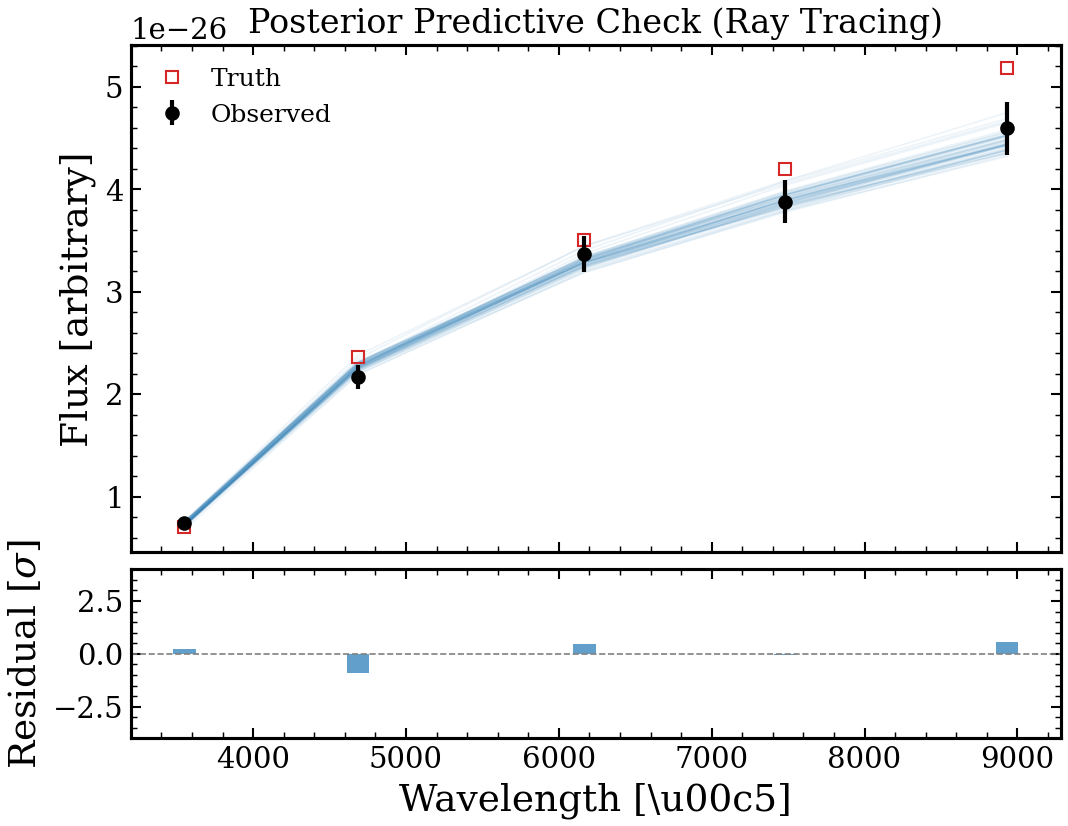

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), height_ratios=[3, 1],
                         sharex=True, gridspec_kw={"hspace": 0.05})

wave_eff = jnp.array([3551, 4686, 6166, 7480, 8932])  # SDSS ugriz

# Draw posterior predictive samples
n_draw = min(50, len(result_rt.samples[spec_stoch.free_params[0]]))
for j in range(n_draw):
    sample_j = {k: (result_rt.samples[k][j] if k == 'psd_xi' else float(result_rt.samples[k][j])) for k in result_rt.samples}
    pred_j = model_stoch.predict_photometry(sample_j)
    axes[0].plot(wave_eff, pred_j, color="C0", alpha=0.08, lw=0.8)

axes[0].errorbar(wave_eff, mock_stoch.flux_obs, yerr=mock_stoch.noise,
                 fmt="o", color="k", zorder=5, label="Observed")
axes[0].plot(wave_eff, mock_stoch.flux_true, "s", ms=6, mfc="none",
             color="C3", zorder=4, label="Truth")
axes[0].set_ylabel("Flux [arbitrary]")
axes[0].set_title("Posterior Predictive Check (Ray Tracing)")
axes[0].legend()

# Residuals
median_pred = np.median(
    np.array([model_stoch.predict_photometry(
        {k: (result_rt.samples[k][j] if k == 'psd_xi' else float(result_rt.samples[k][j])) for k in result_rt.samples}
    ) for j in range(n_draw)]),
    axis=0,
)
residuals = (mock_stoch.flux_obs - median_pred) / mock_stoch.noise
axes[1].axhline(0, color="0.5", ls="--", lw=0.8)
axes[1].bar(wave_eff, residuals, width=150, color="C0", alpha=0.7)
axes[1].set_xlabel("Wavelength [\\u00c5]")
axes[1].set_ylabel("Residual [$\\sigma$]")
axes[1].set_ylim(-4, 4)

chi2_per_band = float(jnp.mean(residuals**2))
print(f"chi^2 / N_bands = {chi2_per_band:.2f}  (expect ~1)")

plt.tight_layout()
plt.show()

## Summary

| Test | Result |
|------|--------|
| **Parametric recovery (NUTS)** | All 7 parameters recovered within 68% CI. Clean posteriors. |
| **Spectroscopy vs photometry** | Spectroscopy tightens posteriors by 2--5x, especially for metallicity and dust. |
| **Stochastic SFH recovery** | RT and geoVI both recover the SFH shape. RT gives tighter posteriors. |
| **PSD $\sigma$** | Well-constrained from a single galaxy (amplitude visible in SFH scatter). |
| **PSD $\tau$** | Poorly constrained -- timescale degeneracy. **Motivates hierarchical inference.** |
| **Burstiness regimes** | Smooth and moderate regimes: excellent recovery. Extreme regime: challenging but unbiased. |
| **Model mismatch** | Fitting a bursty galaxy with a smooth model biases SFR and sSFR. Use the stochastic model. |
| **SNR dependence** | Posteriors widen at low SNR but remain calibrated. SNR > 10 recommended. |

**Next step:** [Tutorial 05 -- Hierarchical PSD Inference](05_hierarchical.ipynb),
where we constrain $\tau_{\rm PSD}$ by sharing it across a population
of galaxies.